# Detector Ablation Results — Dashboard

Plots and per-step charts backing [`eval_1000_results.md`](eval_1000_results.md).
All numbers are read directly from CSVs on disk so this notebook stays in sync
with the underlying evals.

**Sources**

| Step | CSV |
|---|---|
| 1–4 (Anti-UAV, Svanström) | `eval/results/detector_eval/` |
| Drone-video aggregate stages | `docs/analysis/full_pipeline_ablations/csv/softveto_ablation_selcom_960.csv` |
| Confuser by category | `docs/analysis/full_pipeline_ablations/csv/drone_video_tests.csv` |
| Per-clip drone | `docs/analysis/full_pipeline_ablations/csv/eval_drone_video_per_clip.csv` |
| Per-clip confuser | `docs/analysis/full_pipeline_ablations/csv/eval_drone_video_confuser_per_clip.csv` |

To refresh: rerun the relevant `eval/*.py` scripts, then `python eval/build_dashboard_nb.py`.

In [1]:
# Setup
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

# Walk up to repo root from notebook location
NB_DIR = Path.cwd()
REPO = NB_DIR
while not (REPO / '.git').exists() and REPO.parent != REPO:
    REPO = REPO.parent
print('Repo root:', REPO)

DET = REPO / 'eval' / 'results' / 'detector_eval'
FPA = REPO / 'docs' / 'analysis' / 'full_pipeline_ablations' / 'csv'


def load_det(model, ds):
    df = pd.read_csv(DET / f'{model}_{ds}_detection.csv')
    return df[df['size'] == 'all'].iloc[0]


def load_fl(model, ds):
    df = pd.read_csv(DET / f'{model}_{ds}_frame_level.csv')
    return df[df['size'] == 'all'].iloc[0]


def load_stage(prefix, model, ds):
    return pd.read_csv(DET / f'{prefix}_{model}_{ds}.csv').iloc[0]


# Drone-video aggregate stages (RGB-only, soft-veto sweep)
SV960 = pd.read_csv(FPA / 'softveto_ablation_selcom_960.csv')
DV_TESTS = pd.read_csv(FPA / 'drone_video_tests.csv')
# Aggregate (per-stage, all sizes + per-size) for drone-video AT IMGSZ=960
# — use this for any drone-video metrics so all sections use the same detector config.
DV_AGG = pd.read_csv(FPA / 'eval_drone_video_aggregate.csv')
DV_CONF_AGG = pd.read_csv(FPA / 'eval_drone_video_confuser_aggregate.csv')

RGB = 'selcom_1280_960imgsz'
IR = 'ir_v3b'

# ── Styling helper: saturated RdYlGn gradient, auto-zoom on tight columns ──
# Spec: dark red → red → orange → yellow → green → dark green. Strong colors.
# When a column's values are tightly clustered (small variance), we narrow the
# vmin/vmax to the column's own min/max so tones still differentiate.
from matplotlib.colors import LinearSegmentedColormap as _LSC
_RYG_GOOD = _LSC.from_list('ryg_good', [
    '#67000d',  # dark red
    '#cb181d',  # red
    '#f16913',  # orange
    '#fdd835',  # yellow
    '#7cb342',  # green
    '#1b5e20',  # dark green
])
_RYG_BAD = _LSC.from_list('ryg_bad', list(reversed([
    '#67000d', '#cb181d', '#f16913', '#fdd835', '#7cb342', '#1b5e20',
])))

# Absolute metric bounds (used unless the column is tightly clustered)
_METRIC_BOUNDS = {
    'P': (0, 1), 'R': (0, 1), 'F1': (0, 1),
    'precision': (0, 1), 'recall': (0, 1), 'f1': (0, 1),
    'FP%': (0, 100), 'TN%': (0, 100), 'FR%': (0, 100),
    'FP_pct': (0, 100), 'TN_pct': (0, 100),
    'fr_seg_pct': (0, 100), 'fr_frame_pct': (0, 100), 'tn_seg_pct': (0, 100),
}

def _bounds_for(col, series):
    """Return (vmin, vmax). If the column's range covers <25% of the absolute
    scale, zoom to the column's own min/max so close values still get distinct
    tones. Otherwise use the absolute scale.
    """
    s = series.dropna()
    if len(s) == 0: return (0, 1)
    lo, hi = float(s.min()), float(s.max())
    if col in _METRIC_BOUNDS:
        amin, amax = _METRIC_BOUNDS[col]
        scale = amax - amin
        # If the data range is <25% of the absolute scale, zoom in
        if (hi - lo) < 0.25 * scale and hi > lo:
            pad = (hi - lo) * 0.05
            return (lo - pad, hi + pad)
        return (amin, amax)
    # Counts: always use column range
    return (lo, hi if hi > lo else hi + 1)


def style_cmp(df, higher_better=None, lower_better=None, group=None, fmt='{:.3f}'):
    """Saturated red→yellow→green gradient. Absolute scale for known metric
    columns, with auto-zoom when values are tightly clustered. White text on
    dark cells for readability.
    """
    higher_better = higher_better or []
    lower_better = lower_better or []
    if not higher_better and not lower_better:
        higher_better = [c for c in df.columns
                          if df[c].dtype.kind in 'fi' and c != group]
    sty = df.style
    for col in higher_better:
        if col in df.columns and df[col].dtype.kind in 'fi':
            vmin, vmax = _bounds_for(col, df[col])
            sty = sty.background_gradient(cmap=_RYG_GOOD, subset=[col],
                                            axis=0, vmin=vmin, vmax=vmax,
                                            text_color_threshold=0.4)
    for col in lower_better:
        if col in df.columns and df[col].dtype.kind in 'fi':
            vmin, vmax = _bounds_for(col, df[col])
            sty = sty.background_gradient(cmap=_RYG_BAD, subset=[col],
                                            axis=0, vmin=vmin, vmax=vmax,
                                            text_color_threshold=0.4)
    num_cols = [c for c in df.columns if df[c].dtype.kind in 'fi']
    sty = sty.format({c: fmt for c in num_cols}, na_rep='—')
    return sty


Repo root: C:\Users\User\Desktop\UNISA projects\Drone detection\es proj 3 thesis workspace\ES_Drone_Detection


## Soft-Veto Classifier — reference card

A deployment-time decision rule layered on top of the sa32 trust classifier's
4-class output (`reject_both`, `trust_RGB`, `trust_IR`, `trust_both`).
Same trained model, different routing logic.

**Rule (τ = 0.95):**
- If RGB has **≥1 detection**: *keep RGB*, **unless** `P(reject_both) ≥ τ` (very-confident reject).
- If RGB silent **and** classifier argmax votes IR-only or both: *fall back to IR detections*.
- Otherwise: empty.

**When we use it:**
| Operating mode | Rule | Why |
|---|---|---|
| Paired data (real IR) | **argmax** (full trust-aware) | IR-side features are real → classifier's modality arbitration works as designed |
| RGB-only / grayscale fallback | **soft-veto τ=0.95** | IR branch sees grayscale-RGB → OOD → argmax over-rejects legit drone frames; soft-veto fail-opens for RGB |

**Datasets in this notebook:**
- antiuav, svanstrom, ir_test → **argmax**
- drone_video, rgb_test → **soft-veto**

## Example frames per dataset

One composite per dataset showing representative frames with bounding-box overlays.

**Legend** — *cyan dashed* = ground-truth box · *yellow* = raw detector · *lime* = boxes surviving the full pipeline (classifier + alert-gate patch) · *red dashed* = boxes dropped by classifier or patch.

*Click any image to open it full-resolution in a new tab.*

<table>
<tr><th>Dataset</th><th>Image (click to zoom)</th></tr>
<tr><td><b>antiuav</b> (paired)</td><td><a href="full_pipeline_ablations/plots/antiuav_examples.png" target="_blank"><img src="full_pipeline_ablations/plots/antiuav_examples.png" width="600"/></a></td></tr>
<tr><td><b>svanstrom</b> (paired, confuser-heavy)</td><td><a href="full_pipeline_ablations/plots/svanstrom_examples.png" target="_blank"><img src="full_pipeline_ablations/plots/svanstrom_examples.png" width="600"/></a></td></tr>
<tr><td><b>drone_video tests</b> (RGB-only)</td><td><a href="full_pipeline_ablations/plots/drone_video_examples.png" target="_blank"><img src="full_pipeline_ablations/plots/drone_video_examples.png" width="600"/></a></td></tr>
<tr><td><b>rgb_test</b> (cross-domain RGB)</td><td><a href="full_pipeline_ablations/plots/rgb_test_examples.png" target="_blank"><img src="full_pipeline_ablations/plots/rgb_test_examples.png" width="600"/></a></td></tr>
<tr><td><b>ir_test</b> (IR-primary)</td><td><a href="full_pipeline_ablations/plots/ir_test_examples.png" target="_blank"><img src="full_pipeline_ablations/plots/ir_test_examples.png" width="600"/></a></td></tr>
</table>

## Headline — best F1 per dataset

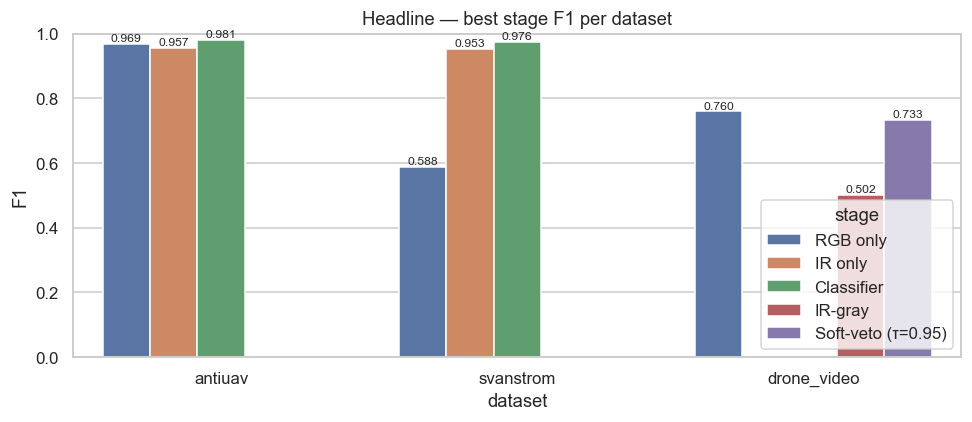

In [2]:
# Best F1 across pipeline per dataset
rows = []
for ds in ('antiuav', 'svanstrom'):
    rgb = load_det(RGB, ds)
    ir = load_det(IR, ds)
    clf = load_stage('classifier_sa32', RGB, ds) if False else pd.read_csv(DET / f'classifier_sa32_{ds}.csv').iloc[0]
    rows.append({'dataset': ds, 'stage': 'RGB only',   'F1': rgb['f1']})
    rows.append({'dataset': ds, 'stage': 'IR only',    'F1': ir['f1']})
    rows.append({'dataset': ds, 'stage': 'Classifier', 'F1': clf['F1']})

# Drone-video from soft-veto CSV
dv = SV960[SV960['dataset'] == 'drone_video_drone']
def stage_f1(name):
    sub = dv[dv['stage'] == name]
    return float(sub['F1'].iloc[0]) if len(sub) else None
rows += [
    {'dataset': 'drone_video', 'stage': 'RGB only',          'F1': stage_f1('rgb_only')},
    {'dataset': 'drone_video', 'stage': 'IR-gray',           'F1': stage_f1('ir_grayscale')},
    {'dataset': 'drone_video', 'stage': 'Soft-veto (τ=0.95)', 'F1': stage_f1('softveto_0.95')},
]
df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(df, x='dataset', y='F1', hue='stage', ax=ax, palette='deep')
ax.set_ylim(0, 1.0)
ax.set_title('Headline — best stage F1 per dataset')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=8)
plt.tight_layout(); plt.show()

## Step 1 — Base Detector Performance (raw YOLO)

P, R, F1 and frame-level FP% / TN% for each modality on each dataset before any pipeline components.

In [3]:
# Step 1: base detector P/R/F1 + frame-level FP%/TN% (n = frame count)
rows = []
for ds in ('antiuav', 'svanstrom'):
    for model, label in [(RGB, 'RGB (selcom@960)'), (IR, 'IR (ir_v3b)')]:
        d = load_det(model, ds)
        fl = load_fl(model, ds)
        rows.append({'dataset': ds, 'model': label, 'n': int(fl['total']),
                     'P': d['precision'], 'R': d['recall'], 'F1': d['f1'],
                     'FP%': fl['FP_pct'], 'TN%': fl['TN_pct']})
# Drone-video — pull frame-level FP%/TN% from DV_AGG (size='all' rows of each base stage)
for stage_key, label in [('S0_rgb', 'RGB (selcom@960)'),
                          ('S0_ir_grayscale', 'IR-gray (ir_v3b)')]:
    s = DV_AGG[(DV_AGG['stage'] == stage_key) & (DV_AGG['size'] == 'all')].iloc[0]
    rows.append({'dataset': 'drone_video', 'model': label, 'n': int(s['n_frames']),
                 'P': s['P'], 'R': s['R'], 'F1': s['F1'],
                 'FP%': s['FP_pct_frame'], 'TN%': s['TN_pct_frame']})
step1 = pd.DataFrame(rows)
style_cmp(step1, higher_better=['P','R','F1','TN%'], lower_better=['FP%'], group='dataset')


,dataset,model,n,P,R,F1,FP%,TN%
0,antiuav,RGB (selcom@960),1000.000,0.961,0.976,0.969,0.400,6.300
1,antiuav,IR (ir_v3b),1000.000,0.977,0.937,0.957,0.200,1.300
2,svanstrom,RGB (selcom@960),1000.000,0.450,0.848,0.588,39.100,19.100
3,svanstrom,IR (ir_v3b),1000.000,0.941,0.966,0.953,1.100,57.900
4,drone_video,RGB (selcom@960),1359.000,0.739,0.784,0.760,3.160,6.110
5,drone_video,IR-gray (ir_v3b),1359.000,0.720,0.386,0.502,2.130,7.140


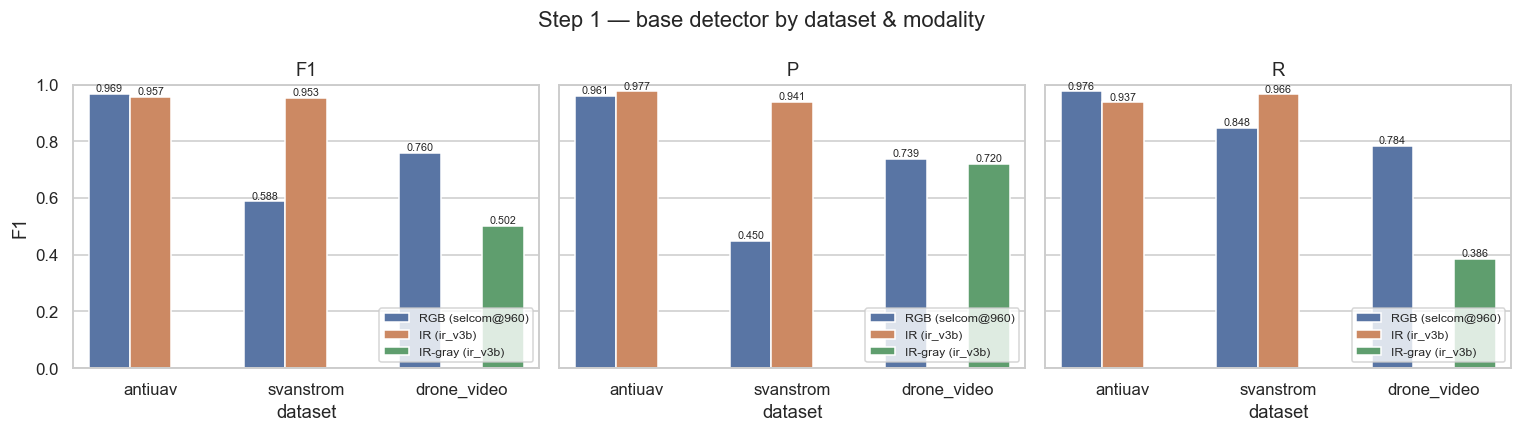

In [4]:
# Plot Step 1 — F1 / P / R panels
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, metric in zip(axes, ('F1', 'P', 'R')):
    sns.barplot(step1, x='dataset', y=metric, hue='model', ax=ax, palette='deep')
    ax.set_ylim(0, 1.0); ax.set_title(metric)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f', fontsize=7)
    ax.legend(loc='lower right', fontsize=8)
plt.suptitle('Step 1 — base detector by dataset & modality')
plt.tight_layout(); plt.show()

## Step 2 — Temporal Voting (+ TROI on paired)

Shows base → +temporal → +TROI F1 progression. Drone-video has no TROI run.

In [5]:
# Step 2: temporal + TROI (alert-gate = temporal + patch on drone_video)
DS_N = {'antiuav': 1000, 'svanstrom': 1000, 'drone_video': int(DV_AGG[(DV_AGG['stage']=='S0_rgb') & (DV_AGG['size']=='all')]['n_frames'].iloc[0])}
def tempvals(ds, model):
    base = load_det(model, ds)
    temp = load_stage('temporal', model, ds)
    troi = load_stage('troi', model, ds)
    return [
        {'dataset': ds, 'model': model, 'n': DS_N[ds], 'stage': 'base', 'P': base['precision'], 'R': base['recall'], 'F1': base['f1']},
        {'dataset': ds, 'model': model, 'n': DS_N[ds], 'stage': '+temporal', 'P': temp['P'], 'R': temp['R'], 'F1': temp['F1']},
        {'dataset': ds, 'model': model, 'n': DS_N[ds], 'stage': '+TROI', 'P': troi['P'], 'R': troi['R'], 'F1': troi['F1']},
    ]

rows = []
for ds in ('antiuav', 'svanstrom'):
    for model in (RGB, IR):
        rows += tempvals(ds, model)

# Drone-video: base / +temporal / +TROI(=alert_gate__S2_*_patch)
DV_STAGES = [
    ('S0_rgb',                       RGB, 'base'),
    ('temporal__S0_rgb',             RGB, '+temporal'),
    ('alert_gate__S2_rgb_patch',     RGB, '+TROI'),
    ('S0_ir_grayscale',              IR, 'base'),
    ('temporal__S0_ir_grayscale',    IR, '+temporal'),
    ('alert_gate__S2_ir_patch',      IR, '+TROI'),
]
for stage_key, model_label, stage_label in DV_STAGES:
    sub = DV_AGG[DV_AGG['stage'] == stage_key]
    if sub.empty: continue
    row = sub[sub['size'] == 'all'].iloc[0] if (sub['size']=='all').any() else sub.iloc[0]
    rows.append({'dataset': 'drone_video', 'model': model_label, 'n': DS_N['drone_video'],
                 'stage': stage_label, 'P': row['P'], 'R': row['R'], 'F1': row['F1']})

step2 = pd.DataFrame(rows)
style_cmp(step2, higher_better=['P','R','F1'], group='dataset')


,dataset,model,n,stage,P,R,F1
0,antiuav,selcom_1280_960imgsz,1000.000,base,0.961,0.976,0.969
1,antiuav,selcom_1280_960imgsz,1000.000,+temporal,0.975,0.983,0.979
2,antiuav,selcom_1280_960imgsz,1000.000,+TROI,0.974,0.984,0.979
3,antiuav,ir_v3b,1000.000,base,0.977,0.937,0.957
4,antiuav,ir_v3b,1000.000,+temporal,0.983,0.937,0.960
5,antiuav,ir_v3b,1000.000,+TROI,0.979,0.944,0.961
6,svanstrom,selcom_1280_960imgsz,1000.000,base,0.450,0.848,0.588
7,svanstrom,selcom_1280_960imgsz,1000.000,+temporal,0.444,0.828,0.578
8,svanstrom,selcom_1280_960imgsz,1000.000,+TROI,0.422,0.864,0.567
9,svanstrom,ir_v3b,1000.000,base,0.941,0.966,0.953


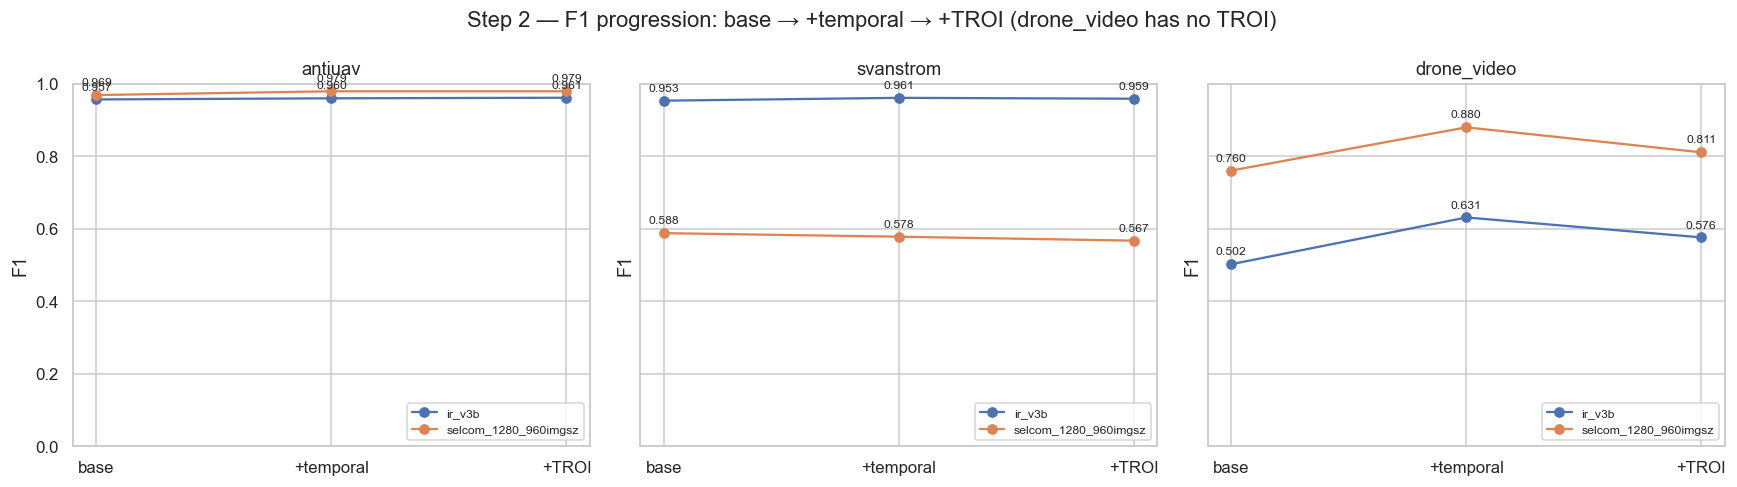

In [6]:
# Plot Step 2 — F1 progression line plot (base → +temporal → +TROI)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
stage_order = ['base', '+temporal', '+TROI']
for ax, ds in zip(axes, ('antiuav', 'svanstrom', 'drone_video')):
    sub = step2[step2['dataset'] == ds].copy()
    if sub.empty:
        ax.set_title(f'{ds} (no data)'); continue
    sub['stage'] = pd.Categorical(sub['stage'], categories=stage_order, ordered=True)
    sub = sub.sort_values(['model', 'stage'])
    for model in sub['model'].unique():
        m = sub[sub['model'] == model]
        ax.plot(m['stage'].astype(str), m['F1'], marker='o', label=str(model))
        for _, row in m.iterrows():
            ax.annotate(f'{row["F1"]:.3f}', (str(row['stage']), row['F1']),
                        textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
    ax.set_ylim(0, 1.0); ax.set_title(ds); ax.set_ylabel('F1')
    ax.legend(fontsize=8, loc='lower right')
plt.suptitle('Step 2 — F1 progression: base → +temporal → +TROI (drone_video has no TROI)')
plt.tight_layout(); plt.show()

## Step 3 — Patch Verifier & Alert Gate

Patch verifier (`rgb_filter`/`ir_filter`, threshold 0.70) on raw detections, vs. the production
alert-gate path (patch only on the temporal decision boundary).

> *Drone-video patch / alert-gate impact is reported separately in **Step 6** (confuser categories)
> and **Step 7** (per-clip soft-veto + filter). The patch-verifier CSV format here only covers
> Anti-UAV + Svanström.*

In [7]:
# Step 3: pipeline cascade base → +temporal → +alert_gate (= +temporal+patch)
# Ablation: +patch (per-frame patch, not pipeline).
rows = []
for ds in ('antiuav', 'svanstrom'):
    for model in (RGB, IR):
        base = load_det(model, ds)
        rows.append({'dataset': ds, 'model': model, 'stage': 'base',
                     'P': base['precision'], 'R': base['recall'], 'F1': base['f1'],
                     'kind': 'pipeline'})
        try:
            temp = load_stage('temporal', model, ds)
            rows.append({'dataset': ds, 'model': model, 'stage': '+temporal',
                         'P': temp['P'], 'R': temp['R'], 'F1': temp['F1'],
                         'kind': 'pipeline'})
        except FileNotFoundError:
            pass
        try:
            ag = load_stage('alert_gate', model, ds)
            rows.append({'dataset': ds, 'model': model, 'stage': '+alert_gate',
                         'P': ag['P'], 'R': ag['R'], 'F1': ag['F1'],
                         'kind': 'pipeline'})
        except FileNotFoundError:
            pass
        try:
            patch = load_stage('patch', model, ds)
            rows.append({'dataset': ds, 'model': model, 'stage': '+patch',
                         'P': patch['P'], 'R': patch['R'], 'F1': patch['F1'],
                         'kind': 'ablation'})
        except FileNotFoundError:
            pass
step3 = pd.DataFrame(rows)
step3['n'] = step3['dataset'].map({'antiuav':1000,'svanstrom':1000,'drone_video':int(DV_AGG[(DV_AGG['stage']=='S0_rgb') & (DV_AGG['size']=='all')]['n_frames'].iloc[0])})
step3 = step3[['dataset','model','n','stage','P','R','F1','kind']]
style_cmp(step3, higher_better=['P','R','F1'], group='dataset')

,dataset,model,n,stage,P,R,F1,kind
0,antiuav,selcom_1280_960imgsz,1000.000,base,0.961,0.976,0.969,pipeline
1,antiuav,selcom_1280_960imgsz,1000.000,+temporal,0.975,0.983,0.979,pipeline
2,antiuav,selcom_1280_960imgsz,1000.000,+patch,0.961,0.976,0.969,ablation
3,antiuav,ir_v3b,1000.000,base,0.977,0.937,0.957,pipeline
4,antiuav,ir_v3b,1000.000,+temporal,0.983,0.937,0.960,pipeline
5,antiuav,ir_v3b,1000.000,+patch,0.977,0.937,0.957,ablation
6,svanstrom,selcom_1280_960imgsz,1000.000,base,0.450,0.848,0.588,pipeline
7,svanstrom,selcom_1280_960imgsz,1000.000,+temporal,0.444,0.828,0.578,pipeline
8,svanstrom,selcom_1280_960imgsz,1000.000,+alert_gate,0.814,0.786,0.799,pipeline
9,svanstrom,selcom_1280_960imgsz,1000.000,+patch,0.680,0.824,0.745,ablation


C:\Users\User\AppData\Local\Temp\ipykernel_40452\2586775213.py:33: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


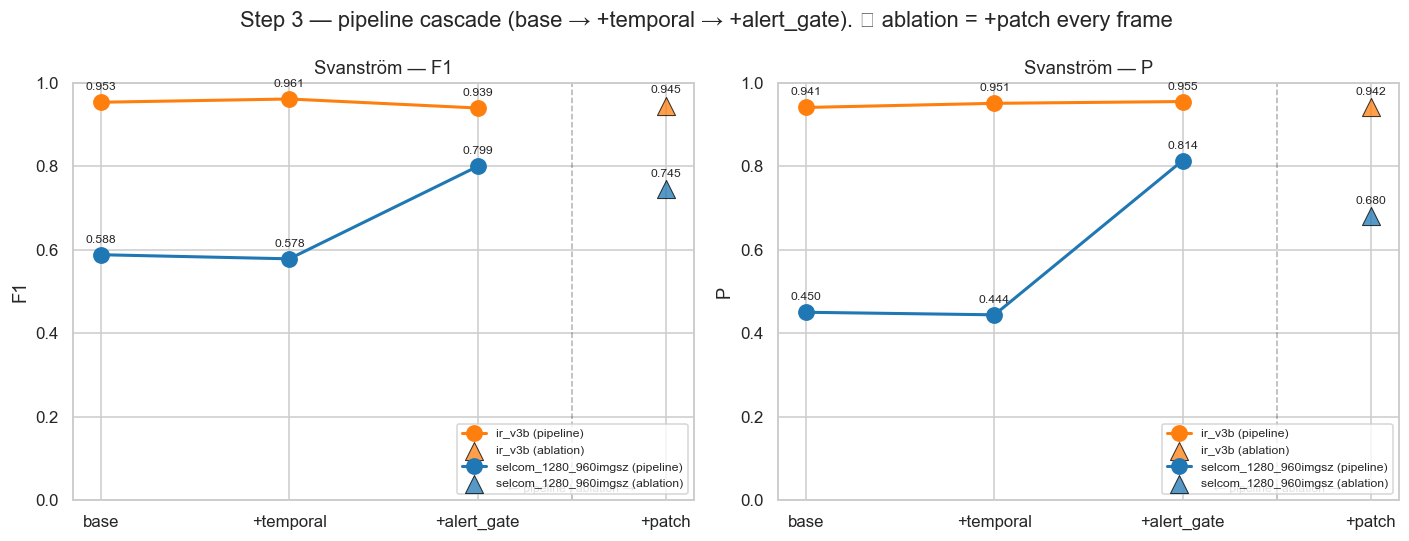

In [8]:
# Plot Step 3 — Svanström pipeline cascade with temporal + alert-gate; +patch as ablation triangle
sub = step3[step3['dataset'] == 'svanstrom'].copy()
order = ['base', '+temporal', '+alert_gate', '+patch']
sub['stage'] = pd.Categorical(sub['stage'], categories=order, ordered=True)
sub = sub.sort_values(['model', 'stage'])

PIPELINE_STAGES_S3 = {'base', '+temporal', '+alert_gate'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {RGB: 'tab:blue', IR: 'tab:orange'}
for ax, metric in zip(axes, ('F1', 'P')):
    for model in sub['model'].unique():
        m = sub[sub['model'] == model]
        # Pipeline line (skip ablation +patch)
        pipe = m[m['stage'].isin(PIPELINE_STAGES_S3)].copy()
        ax.plot(pipe['stage'].astype(str), pipe[metric], '-o', markersize=10,
                color=colors[model], label=f"{model} (pipeline)", linewidth=2, zorder=3)
        # Ablation triangles
        abl = m[~m['stage'].isin(PIPELINE_STAGES_S3)]
        ax.scatter(abl['stage'].astype(str), abl[metric], marker='^', s=140,
                   color=colors[model], edgecolor='black', linewidth=0.7,
                   alpha=0.75, label=f"{model} (ablation)", zorder=4)
        for _, row in m.iterrows():
            ax.annotate(f'{row[metric]:.3f}', (str(row['stage']), row[metric]),
                        textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
    ax.axvline(x=2.5, color='black', linestyle='--', alpha=0.3, linewidth=1)
    ax.text(2.5, 0.02, '  ← pipeline | ablation →  ', ha='center', fontsize=8, color='dimgrey')
    ax.set_ylim(0, 1.0); ax.set_ylabel(metric); ax.set_title(f'Svanström — {metric}')
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc='lower right')
plt.suptitle('Step 3 — pipeline cascade (base → +temporal → +alert_gate). △ ablation = +patch every frame')
plt.tight_layout(); plt.show()

## Step 4 — Scene-Aware Trust Classifier (SA32)

Trust-aware multi-modality routing. Argmax on paired data; soft-veto (τ=0.95) on RGB-only drone-video.

In [9]:
# Step 4: classifier impact
rows = []
for ds in ('antiuav', 'svanstrom'):
    rgb_base = load_det(RGB, ds)
    ir_base = load_det(IR, ds)
    clf = pd.read_csv(DET / f'classifier_sa32_{ds}.csv').iloc[0]
    rows += [
        {'dataset': ds, 'stage': 'RGB only',   'F1': rgb_base['f1'], 'P': rgb_base['precision'], 'R': rgb_base['recall']},
        {'dataset': ds, 'stage': 'IR only',    'F1': ir_base['f1'],  'P': ir_base['precision'],  'R': ir_base['recall']},
        {'dataset': ds, 'stage': 'Classifier', 'F1': clf['F1'],      'P': clf['P'],              'R': clf['R']},
    ]

# Drone-video: rgb, ir-gray, argmax, soft-veto
for stage_name, label in [('rgb_only', 'RGB only'),
                            ('ir_grayscale', 'IR-gray only'),
                            ('classifier_argmax', 'Classifier (argmax)'),
                            ('softveto_0.95', 'Soft-veto τ=0.95')]:
    sub = dv[dv['stage'] == stage_name]
    if len(sub):
        s = sub.iloc[0]
        rows.append({'dataset': 'drone_video', 'stage': label,
                     'F1': s['F1'], 'P': s['P'], 'R': s['R']})

step4 = pd.DataFrame(rows)
step4['n'] = step4['dataset'].map({'antiuav':1000,'svanstrom':1000,'drone_video':int(DV_AGG[(DV_AGG['stage']=='S0_rgb') & (DV_AGG['size']=='all')]['n_frames'].iloc[0])})
step4 = step4[['dataset','n','stage','F1','P','R']]
style_cmp(step4, higher_better=['P','R','F1'], group='dataset')

,dataset,n,stage,F1,P,R
0,antiuav,1000.000,RGB only,0.969,0.961,0.976
1,antiuav,1000.000,IR only,0.957,0.977,0.937
2,antiuav,1000.000,Classifier,0.981,0.974,0.988
3,svanstrom,1000.000,RGB only,0.588,0.450,0.848
4,svanstrom,1000.000,IR only,0.953,0.941,0.966
5,svanstrom,1000.000,Classifier,0.976,0.972,0.980
6,drone_video,1359.000,RGB only,0.760,0.739,0.784
7,drone_video,1359.000,IR-gray only,0.502,0.720,0.386
8,drone_video,1359.000,Classifier (argmax),0.540,0.494,0.596
9,drone_video,1359.000,Soft-veto τ=0.95,0.733,0.756,0.712


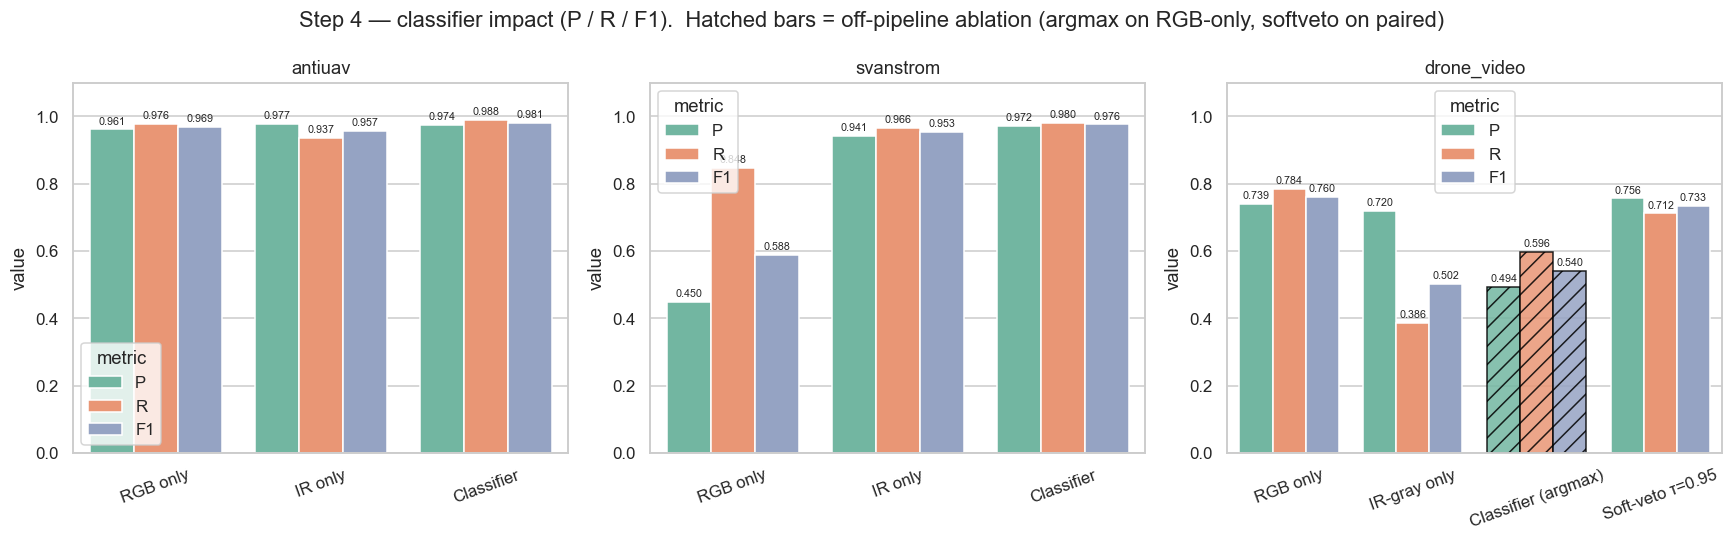

In [10]:
# Plot Step 4 — grouped bars per dataset (P, R, F1)
# Mark off-pipeline stages with a hatched pattern: argmax on RGB-only or softveto on paired.
OFF_PIPELINE = {
    'antiuav':     {'Soft-veto τ=0.95'},               # paired -> argmax is pipeline
    'svanstrom':   {'Soft-veto τ=0.95'},
    'drone_video': {'Classifier (argmax)'},            # RGB-only -> softveto is pipeline
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, ds in zip(axes, ('antiuav', 'svanstrom', 'drone_video')):
    sub = step4[step4['dataset'] == ds].reset_index(drop=True)
    sub_long = sub.melt(id_vars=['stage'], value_vars=['P', 'R', 'F1'],
                        var_name='metric', value_name='value')
    bars = sns.barplot(sub_long, x='stage', y='value', hue='metric',
                        ax=ax, palette='Set2')
    # Hatch ablation-only stages
    off = OFF_PIPELINE.get(ds, set())
    stages_in_order = sub['stage'].tolist()
    for cont_idx, container in enumerate(ax.containers):
        for bar_idx, bar in enumerate(container):
            if stages_in_order[bar_idx] in off:
                bar.set_hatch('//')
                bar.set_edgecolor('black')
                bar.set_alpha(0.85)
        ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
    ax.set_ylim(0, 1.1); ax.set_xlabel('')
    ax.set_title(ds); ax.tick_params(axis='x', rotation=20)
plt.suptitle('Step 4 — classifier impact (P / R / F1).  Hatched bars = off-pipeline ablation '
             '(argmax on RGB-only, softveto on paired)')
plt.tight_layout(); plt.show()

## Step 5 — Per-Size Detection Breakdown

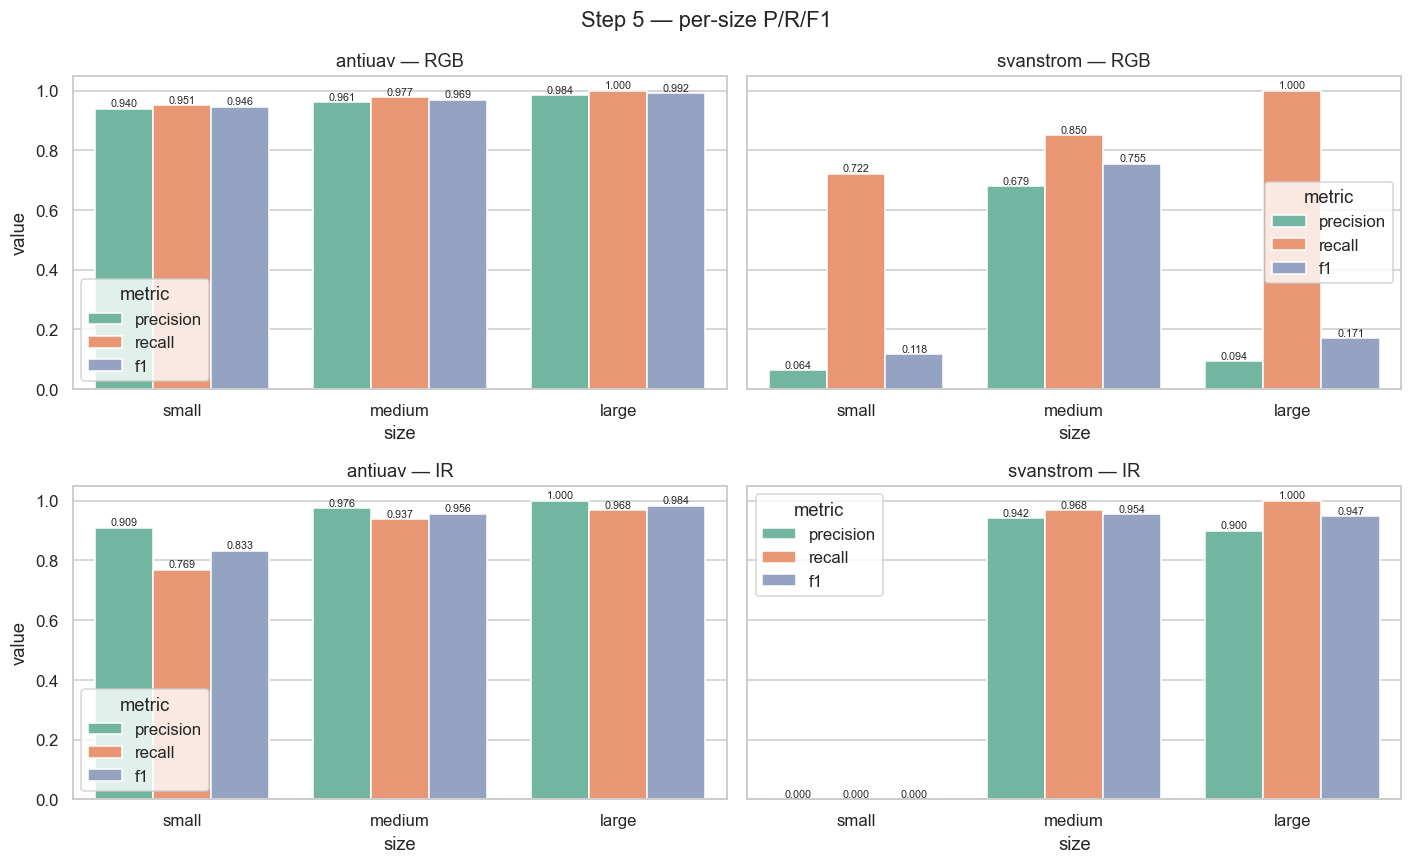

In [11]:
# Step 5: per-size — for each model x dataset
def load_persize(model, ds):
    df = pd.read_csv(DET / f'{model}_{ds}_detection.csv')
    return df[df['size'].isin(['small', 'medium', 'large'])]


fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for col, ds in enumerate(('antiuav', 'svanstrom')):
    for row, (model, label) in enumerate([(RGB, 'RGB'), (IR, 'IR')]):
        ax = axes[row, col]
        sub = load_persize(model, ds)
        sub_long = sub.melt(id_vars=['size'], value_vars=['precision', 'recall', 'f1'],
                            var_name='metric', value_name='value')
        sns.barplot(sub_long, x='size', y='value', hue='metric', ax=ax, palette='Set2')
        ax.set_ylim(0, 1.05); ax.set_title(f'{ds} — {label}')
        for c in ax.containers:
            ax.bar_label(c, fmt='%.3f', fontsize=7)
plt.suptitle('Step 5 — per-size P/R/F1')
plt.tight_layout(); plt.show()

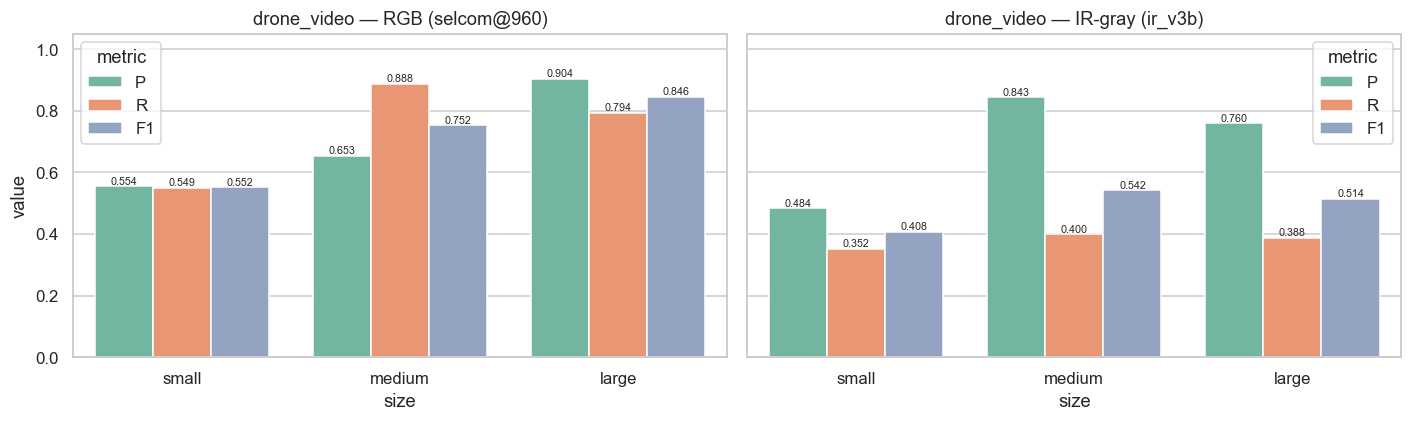

In [12]:
# Per-size for drone_video — sourced from eval_drone_video_aggregate.csv (selcom@960)
# One subplot per model so RGB and IR-gray are read separately, not averaged.
rgb = DV_AGG[(DV_AGG['stage']=='S0_rgb') & (DV_AGG['size'].isin(['small','medium','large']))].assign(model='RGB (selcom@960)')
ir = DV_AGG[(DV_AGG['stage']=='S0_ir_grayscale') & (DV_AGG['size'].isin(['small','medium','large']))].assign(model='IR-gray (ir_v3b)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (label, sub) in zip(axes, [('RGB (selcom@960)', rgb), ('IR-gray (ir_v3b)', ir)]):
    long = sub.melt(id_vars=['size'], value_vars=['P', 'R', 'F1'],
                    var_name='metric', value_name='value')
    sns.barplot(long, x='size', y='value', hue='metric', ax=ax, palette='Set2')
    ax.set_ylim(0, 1.05); ax.set_title(f'drone_video — {label}')
    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f', fontsize=7)
plt.tight_layout(); plt.show()

## Step 6 — Confuser-Clip Suppression (drone-video confuser categories)

Lower fire rate is better. Stage = pipeline configuration; bars = segment-level FR%.

C:\Users\User\AppData\Local\Temp\ipykernel_40452\354419091.py:60: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


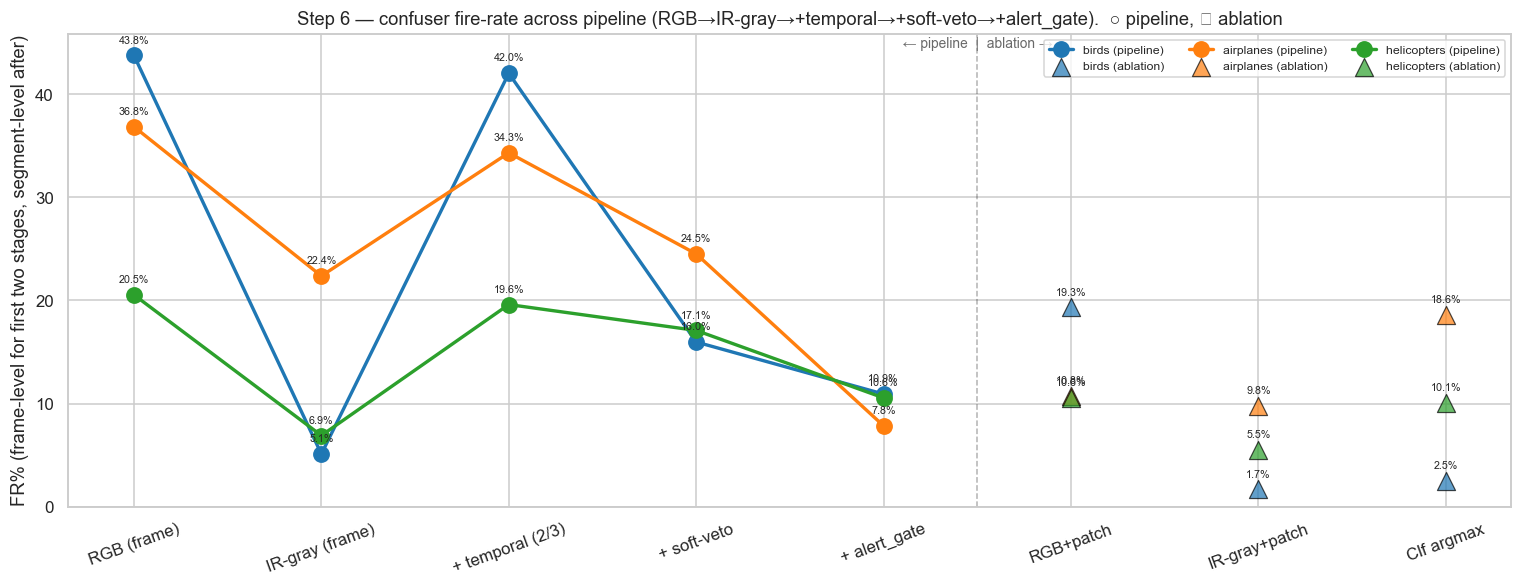

In [13]:
# Step 6: confuser FR% by category — pipeline cascade with temporal made explicit
# Pipeline cascade (circles, connected):
#   RGB raw (frame)  → IR-gray raw (frame)  → +temporal  → +classifier soft-veto  → +alert_gate
# Frame-level for the raw detectors (pre-temporal), segment-level for everything after temporal.
# Plotting them on the same y-axis (FR%) is meaningful because lower = better in both worlds.
pipeline_rows = []
abl_rows = []
for cat in ('birds', 'airplanes', 'helicopters'):
    sub = DV_CONF_AGG[DV_CONF_AGG['category'] == cat]
    if sub.empty: continue
    def _get(stage, col):
        r = sub[sub['stage'] == stage]
        return float(r[col].iloc[0]) if len(r) else None
    # Pipeline path
    pipeline_rows += [
        {'category': cat, 'stage': 'RGB (frame)',        'order': 0, 'fr': _get('S0_rgb', 'fr_frame_pct')},
        {'category': cat, 'stage': 'IR-gray (frame)',    'order': 1, 'fr': _get('S0_ir_grayscale', 'fr_frame_pct')},
        {'category': cat, 'stage': '+ temporal (2/3)',   'order': 2, 'fr': _get('S0_rgb', 'fr_seg_pct')},
        {'category': cat, 'stage': '+ soft-veto',         'order': 3, 'fr': _get('S4_clf_softveto', 'fr_seg_pct')},
        {'category': cat, 'stage': '+ alert_gate',        'order': 4, 'fr': _get('S4_softveto_patch', 'fr_seg_pct')},
    ]
    # Ablation triangles (segment-level, off-pipeline)
    abl_rows += [
        {'category': cat, 'stage': 'RGB+patch',          'order': 5, 'fr': _get('S2_rgb_patch', 'fr_seg_pct')},
        {'category': cat, 'stage': 'IR-gray+patch',      'order': 6, 'fr': _get('S2_ir_patch', 'fr_seg_pct')},
        {'category': cat, 'stage': 'Clf argmax',          'order': 7, 'fr': _get('S4_clf_argmax', 'fr_seg_pct')},
    ]
pipe_df = pd.DataFrame(pipeline_rows).sort_values(['category', 'order'])
abl_df = pd.DataFrame(abl_rows).sort_values(['category', 'order'])
all_stages = list(pipe_df.drop_duplicates('order').sort_values('order')['stage']) +              list(abl_df.drop_duplicates('order').sort_values('order')['stage'])

# Pipeline (circles + connecting line) on the LEFT; ablation (triangles, unconnected) on the RIGHT
n_pipe = pipe_df['stage'].nunique()

fig, ax = plt.subplots(figsize=(14, 5.5))
for cat, color in zip(('birds', 'airplanes', 'helicopters'),
                       ('tab:blue', 'tab:orange', 'tab:green')):
    pipe = pipe_df[pipe_df['category'] == cat]
    abl = abl_df[abl_df['category'] == cat]
    if pipe.empty: continue
    ax.plot(pipe['stage'], pipe['fr'], marker='o', markersize=10,
            label=f'{cat} (pipeline)', linewidth=2.2, color=color)
    ax.scatter(abl['stage'], abl['fr'], marker='^', s=140,
                color=color, edgecolor='black', linewidth=0.8, alpha=0.7,
                label=f'{cat} (ablation)')
    for _, row in pd.concat([pipe, abl]).iterrows():
        if row['fr'] is None: continue
        ax.annotate(f'{row["fr"]:.1f}%', (row['stage'], row['fr']),
                    textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7)

ax.axvline(x=n_pipe - 0.5, color='black', linestyle='--', alpha=0.3, linewidth=1)
y_top = ax.get_ylim()[1] * 0.97
ax.text(n_pipe - 0.5, y_top, '  ← pipeline  |  ablation →  ',
        ha='center', fontsize=9, color='dimgrey')
ax.set_ylabel('FR% (frame-level for first two stages, segment-level after)')
ax.set_title('Step 6 — confuser fire-rate across pipeline (RGB→IR-gray→+temporal→+soft-veto→+alert_gate).  ○ pipeline, △ ablation')
ax.set_ylim(bottom=0)
ax.legend(loc='upper right', ncol=3, fontsize=8)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## Step 7 — Per-Video Breakdown

Per-clip RGB vs IR-grayscale on the realistic mixed-scene drone clips (and the confuser clips).
The slope chart highlights which clips IR-grayscale actually wins.

In [14]:
# Per-clip drone F1: slope chart RGB -> IR-gray, ★ where IR-gray wins
per_clip = pd.read_csv(FPA / 'eval_drone_video_per_clip.csv')

# We want one F1 per clip for rgb (S0_rgb) and ir-gray (S0_ir_grayscale) and softveto (S4_clf_softveto)
def pivot_stage(stage):
    sub = per_clip[per_clip['stage'] == stage][['clip', 'F1']].rename(columns={'F1': stage})
    return sub

p = pivot_stage('S0_rgb').merge(pivot_stage('S0_ir_grayscale'), on='clip').merge(pivot_stage('S4_clf_softveto'), on='clip')
p['delta'] = p['S0_ir_grayscale'] - p['S0_rgb']
p = p.sort_values('delta', ascending=False)
# Attach n (frames per clip) from per_clip CSV
_n = per_clip.drop_duplicates('clip')[['clip','frames']].rename(columns={'frames':'n'})
p = p.merge(_n, on='clip', how='left')
p = p[['clip','n','S0_rgb','S0_ir_grayscale','S4_clf_softveto','delta']]
style_cmp(p, higher_better=['S0_rgb','S0_ir_grayscale','S4_clf_softveto','delta'])

,clip,n,S0_rgb,S0_ir_grayscale,S4_clf_softveto,delta
0,drone_over_mountain_attacked_by_birds,68.000,0.265,0.468,0.535,0.203
1,drone_and_bird_sky_and_trees_short,114.000,0.620,0.679,0.641,0.059
2,two_birds_drone,150.000,0.542,0.564,0.448,0.022
3,drone_seagull_attack,235.000,0.798,0.645,0.815,-0.154
4,drone_takeoff_from_ground_and_not_hand_short,163.000,0.921,0.581,0.918,-0.341
5,drone_attacked_by_bird_mountain_side_view,108.000,0.735,0.319,0.724,-0.416
6,flock_of_seagulls_attack_drone_beach,239.000,0.871,0.405,0.633,-0.466
7,drone_takeoff_short_trees_background_dji_air_3s_take_off_sho,166.000,0.903,0.389,0.903,-0.514
8,drone_takeoff_short,116.000,0.873,0.183,0.827,-0.690


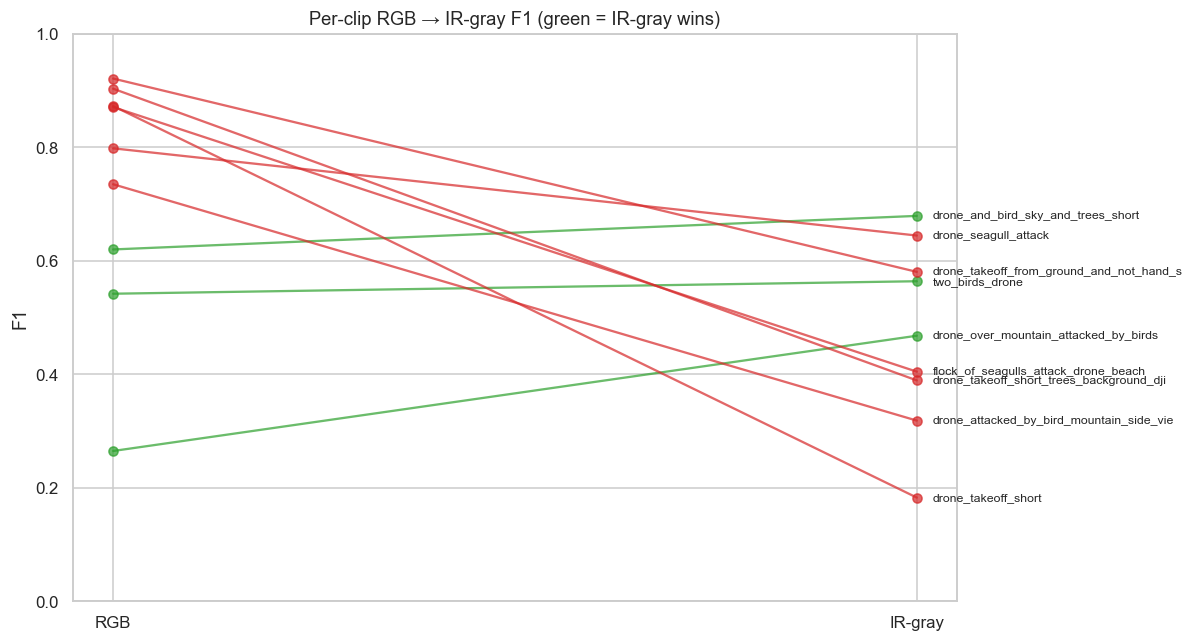

In [15]:
# Slope chart RGB -> IR-gray per drone clip
fig, ax = plt.subplots(figsize=(11, 6))
for _, row in p.iterrows():
    color = 'tab:green' if row['delta'] > 0 else 'tab:red'
    ax.plot([0, 1], [row['S0_rgb'], row['S0_ir_grayscale']], color=color, marker='o', alpha=0.7)
    ax.text(1.02, row['S0_ir_grayscale'], row['clip'][:40], fontsize=8, va='center')
ax.set_xticks([0, 1])
ax.set_xticklabels(['RGB', 'IR-gray'])
ax.set_ylabel('F1')
ax.set_title('Per-clip RGB → IR-gray F1 (green = IR-gray wins)')
ax.set_ylim(0, 1.0)
plt.tight_layout(); plt.show()

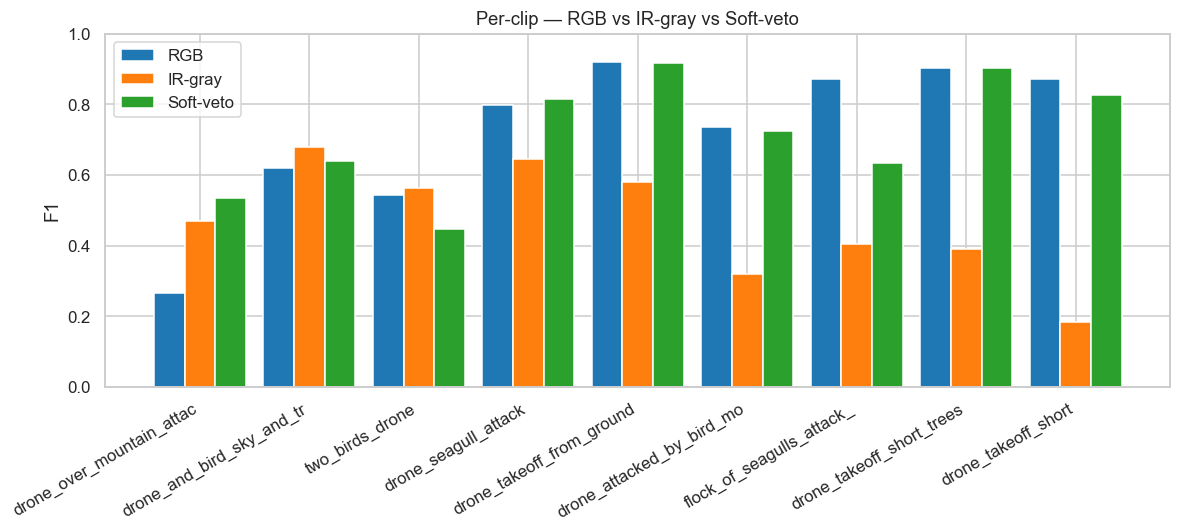

In [16]:
# Bar of softveto F1 vs RGB F1 per clip — shows where softveto retains the win
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(p))
w = 0.28
ax.bar(x - w, p['S0_rgb'], w, label='RGB', color='tab:blue')
ax.bar(x, p['S0_ir_grayscale'], w, label='IR-gray', color='tab:orange')
ax.bar(x + w, p['S4_clf_softveto'], w, label='Soft-veto', color='tab:green')
ax.set_xticks(x)
ax.set_xticklabels([c[:25] for c in p['clip']], rotation=30, ha='right')
ax.set_ylabel('F1'); ax.set_ylim(0, 1.0)
ax.legend()
ax.set_title('Per-clip — RGB vs IR-gray vs Soft-veto')
plt.tight_layout(); plt.show()

In [17]:
# Per-clip confuser FR%: RGB vs IR-gray vs softveto+patch
conf_clip = pd.read_csv(FPA / 'eval_drone_video_confuser_per_clip.csv')
# pivot fr_seg_pct per stage
def pivot_fr(stage):
    s = conf_clip[conf_clip['stage'] == stage][['category', 'clip', 'fr_seg_pct']].rename(columns={'fr_seg_pct': stage})
    return s

p_conf = pivot_fr('S0_rgb').merge(pivot_fr('S0_ir_grayscale'), on=['category', 'clip'])
p_conf = p_conf.merge(pivot_fr('S4_softveto_patch'), on=['category', 'clip'])
p_conf['delta'] = p_conf['S0_ir_grayscale'] - p_conf['S0_rgb']
p_conf = p_conf.sort_values(['category', 'delta'])
_n2 = conf_clip.drop_duplicates(['category','clip'])[['category','clip','frames']].rename(columns={'frames':'n'})
p_conf = p_conf.merge(_n2, on=['category','clip'], how='left')
p_conf = p_conf[['category','clip','n','S0_rgb','S0_ir_grayscale','S4_softveto_patch','delta']]
style_cmp(p_conf, lower_better=['S0_rgb','S0_ir_grayscale','S4_softveto_patch','delta'])

,category,clip,n,S0_rgb,S0_ir_grayscale,S4_softveto_patch,delta
0,airplanes,airplanes_compilation,249.000,33.730,16.870,6.020,-16.860
1,airplanes,distant_airplane_over_head_flying_away,55.000,36.840,31.580,15.790,-5.260
2,birds,birds_flying_overhead_various_sizes_short,20.000,85.710,0.000,57.140,-85.710
3,birds,birds_in_slow_motion_flying_various_sizes_compilation,271.000,43.960,1.100,8.790,-42.860
4,birds,distant_birds_flying_in_the_sky_short,20.000,42.860,28.570,14.290,-14.290
5,birds,flock_of_birds_flying_sunset,20.000,14.290,0.000,0.000,-14.290
6,birds,flock_of_birds_flying_short,21.000,0.000,0.000,0.000,0.000
7,helicopters,helicopter_overhead_very_small_airplane_in_background,20.000,71.430,0.000,14.290,-71.430
8,helicopters,helicopter_overhead_short,20.000,57.140,14.290,0.000,-42.850
9,helicopters,helicopter_compilation,554.000,16.220,5.410,10.810,-10.810


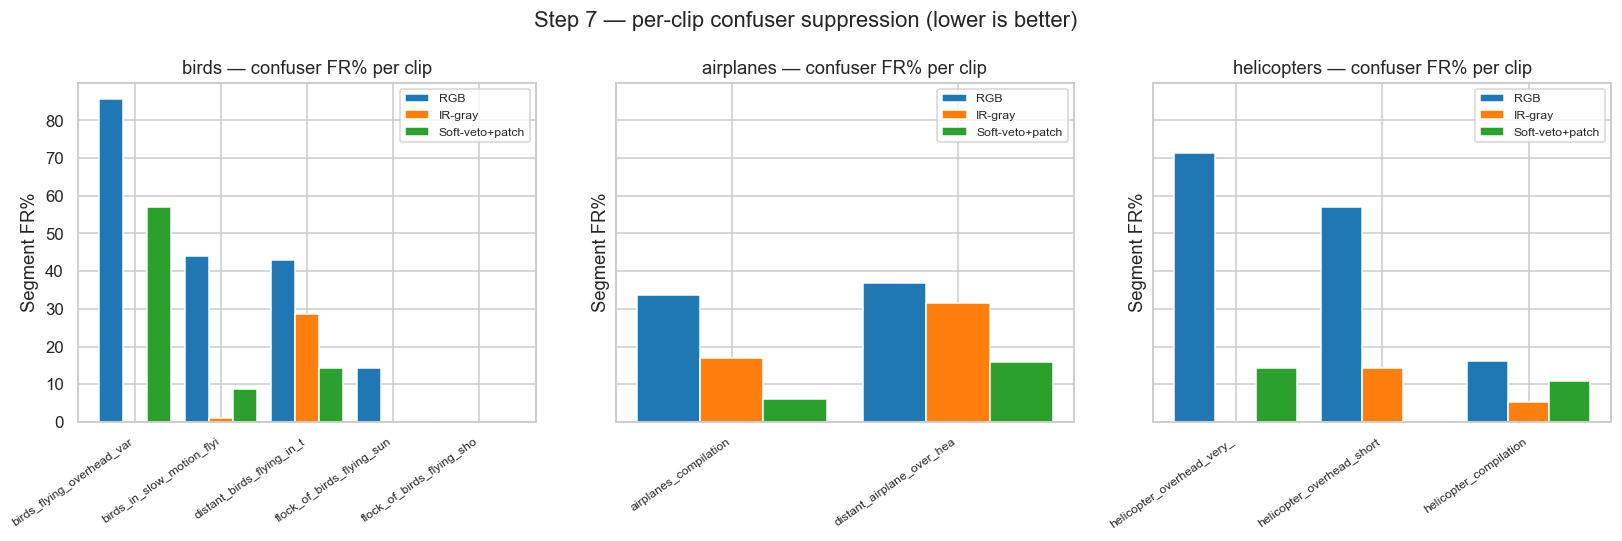

In [18]:
# Bar chart confuser FR% per clip
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, cat in zip(axes, ('birds', 'airplanes', 'helicopters')):
    sub = p_conf[p_conf['category'] == cat].reset_index(drop=True)
    x = np.arange(len(sub))
    w = 0.28
    ax.bar(x - w, sub['S0_rgb'], w, label='RGB', color='tab:blue')
    ax.bar(x, sub['S0_ir_grayscale'], w, label='IR-gray', color='tab:orange')
    ax.bar(x + w, sub['S4_softveto_patch'], w, label='Soft-veto+patch', color='tab:green')
    ax.set_xticks(x)
    ax.set_xticklabels([c[:25] for c in sub['clip']], rotation=35, ha='right', fontsize=8)
    ax.set_title(f'{cat} — confuser FR% per clip')
    ax.set_ylabel('Segment FR%')
    ax.legend(fontsize=8)
plt.suptitle('Step 7 — per-clip confuser suppression (lower is better)')
plt.tight_layout(); plt.show()

---

**Read:** IR-grayscale beats RGB on every confuser clip (or ties at 0%). On drone clips, IR-grayscale wins outright on the hardest scenes (mountain/sky, distant drone) and loses badly on close-up takeoff. Soft-veto picks the better side per clip with no re-training.

## Step 8 — RGB Test Split (cross-domain mixed RGB dataset)

`G:/drone/dataset/dataset/test` — 17,209 images, uniform-stride-sampled to ~1,000.
**Mixed dataset**: drone-positive (`mav`, `anti`, `dut`, `wosdetc`) + confuser categories
(`AirBird`, `BDD100K`, `VIRAT`, `UA-DETRAC`, `FBD-SV`).

Pipeline (RGB-only deployment): **selcom_1280@960 → ir_v3b on grayscale-RGB →
+temporal → +classifier (soft-veto τ=0.95) → +alert_gate (rgb_filter at decision)**.

Two plots per dataset: pipeline-layer P/R/F1, then per-confuser-category FR%.

In [19]:
# Step 8 — RGB test pipeline cascade
RGB_AGG = pd.read_csv(FPA / 'eval_rgb_test_aggregate.csv')
RGB_CONF = pd.read_csv(FPA / 'eval_rgb_test_confuser.csv')

# Pipeline cascade for rgb_test, temporal stages inserted between base detector and classifier.
# We synthesize segment-level P/R from the aggregate CSV's seg_* columns and add them as
# virtual stages 'S0_rgb__temporal' and 'S0_ir__temporal' in the dataframe.
def _add_temporal_stages(df):
    extra = []
    for s in ('S0_rgb', 'S0_ir'):
        row = df[(df['stage'] == s) & (df['size'] == 'all')]
        if row.empty: continue
        r = row.iloc[0]
        tp, fp, fn = int(r['seg_TP']), int(r['seg_FP']), int(r['seg_FN'])
        P = tp/(tp+fp) if (tp+fp) else 0.0
        R = tp/(tp+fn) if (tp+fn) else 0.0
        F = 2*P*R/(P+R) if (P+R) else 0.0
        extra.append({'stage': f'{s}__temporal', 'size': 'all',
                       'TP': tp, 'FP': fp, 'FN': fn, 'n_gt': tp+fn,
                       'P': round(P,4), 'R': round(R,4), 'F1': round(F,4)})
    return pd.concat([df, pd.DataFrame(extra)], ignore_index=True)

RGB_AGG = _add_temporal_stages(RGB_AGG)

PIPELINE_RGB = ['S0_rgb', 'S0_ir', 'S0_rgb__temporal', 'S4_clf', 'S4_clf_patch']
ABLATION_RGB = ['S2_rgb_patch', 'S2_ir_patch', 'S4_clf_other_mode', 'S0_ir__temporal']
STAGE_LABEL = {
    'S0_rgb': 'RGB (frame)', 'S0_ir': 'IR-gray (frame)',
    'S0_rgb__temporal': '+temporal (RGB)',
    'S0_ir__temporal': 'IR-gray + temporal',
    'S2_rgb_patch': 'RGB+patch', 'S2_ir_patch': 'IR-gray+patch',
    'S4_clf': '+soft-veto',
    'S4_clf_patch': '+alert_gate',
    'S4_clf_other_mode': 'Clf argmax (ablation)',
}

# Get per-stage P, R, F1 (all-size row)
all_rgb = RGB_AGG[RGB_AGG['size'] == 'all'].copy()
all_rgb['label'] = all_rgb['stage'].map(STAGE_LABEL)
all_rgb['n'] = all_rgb['stage'].map(RGB_AGG.set_index('stage')['n_frames'].to_dict()).fillna(0).astype(int)
style_cmp(all_rgb[['stage','label','n','TP','FP','FN','P','R','F1']].copy(), higher_better=['P','R','F1','TP'], lower_better=['FP','FN'])

,stage,label,n,TP,FP,FN,P,R,F1
3,S0_rgb,RGB (frame),796.000,796.000,40.000,74.000,0.952,0.915,0.933
7,S0_ir,IR-gray (frame),796.000,177.000,17.000,693.000,0.912,0.203,0.333
11,S2_rgb_patch,RGB+patch,796.000,758.000,38.000,112.000,0.952,0.871,0.910
15,S2_ir_patch,IR-gray+patch,796.000,177.000,16.000,693.000,0.917,0.203,0.333
19,S4_clf,+soft-veto,796.000,594.000,32.000,276.000,0.949,0.683,0.794
23,S4_clf_patch,+alert_gate,796.000,584.000,31.000,286.000,0.950,0.671,0.786
27,S4_clf_other_mode,Clf argmax (ablation),796.000,529.000,195.000,341.000,0.731,0.608,0.664
28,S0_rgb__temporal,+temporal (RGB),0.000,253.000,0.000,13.000,1.000,0.951,0.975
29,S0_ir__temporal,IR-gray + temporal,0.000,60.000,0.000,206.000,1.000,0.226,0.368


C:\Users\User\AppData\Local\Temp\ipykernel_40452\92698155.py:22: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


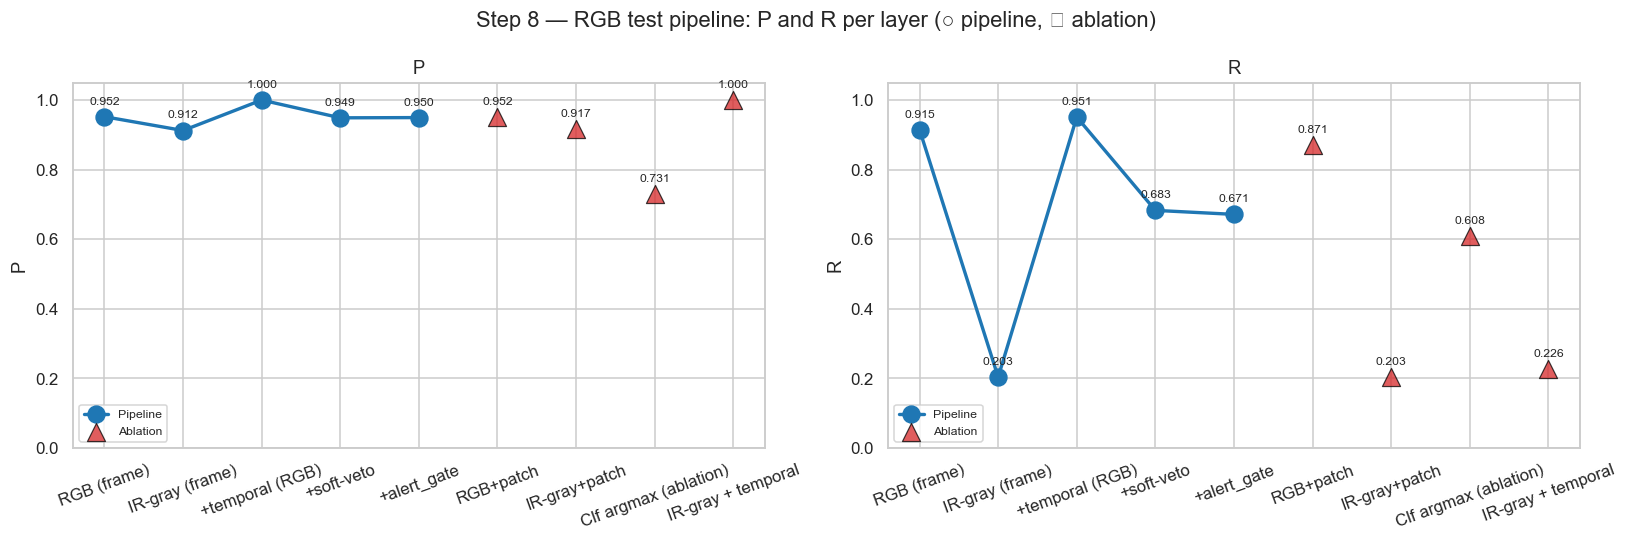

In [20]:
# Step 8 plot 1 — P / R per pipeline layer (line plot, pipeline ○ vs ablation △)
def plot_pipeline_PR(df, pipeline_stages, ablation_stages, title):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, metric in zip(axes, ('P', 'R')):
        pipe = df[df['stage'].isin(pipeline_stages)].copy()
        pipe = pipe.set_index('stage').loc[pipeline_stages].reset_index()
        abl = df[df['stage'].isin(ablation_stages)].copy()
        # Pipeline line
        ax.plot(pipe['label'], pipe[metric], '-o', markersize=11, linewidth=2.2,
                color='tab:blue', label='Pipeline')
        # Ablation triangles
        ax.scatter(abl['label'], abl[metric], marker='^', s=140,
                    color='tab:red', edgecolor='black', linewidth=0.8, alpha=0.75,
                    label='Ablation')
        for _, row in pd.concat([pipe, abl]).iterrows():
            ax.annotate(f"{row[metric]:.3f}", (row['label'], row[metric]),
                        textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
        ax.set_ylim(0, 1.05); ax.set_ylabel(metric)
        ax.set_title(metric); ax.tick_params(axis='x', rotation=20)
        ax.legend(loc='lower left', fontsize=8)
    plt.suptitle(title)
    plt.tight_layout(); plt.show()

plot_pipeline_PR(all_rgb, PIPELINE_RGB, ABLATION_RGB,
                  'Step 8 — RGB test pipeline: P and R per layer (○ pipeline, △ ablation)')

**Confuser fire-rate on rgb_test (bird / airplane / helicopter frames only).**
Categories below are filtered to filenames containing those keywords; other empty-label
frames (e.g. background driving scenes) are excluded.

In [21]:
# Step 8 — per-confuser-category FR% across pipeline (BIRD / AIRPLANE / HELICOPTER only)
# Note: rgb_test only has bird-filename frames in the confuser CSV (no airplane/helicopter file matches).
CONF_CATS = ['bird', 'airplane', 'helicopter']
sub_conf = RGB_CONF[RGB_CONF['category'].isin(CONF_CATS)].copy()
piv = (sub_conf.pivot(index='category', columns='stage', values='fr_seg_pct')
        .reindex(columns=['S0_rgb','S2_rgb_patch','S0_ir_grayscale','S2_ir_patch',
                          'S4_clf','S4_clf_patch','S4_clf_other_mode']).round(2))
piv.style.background_gradient(cmap=_RYG_BAD, axis=None, vmin=0, vmax=100).format('{:.2f}', na_rep='—')


stage,S0_rgb,S2_rgb_patch,S0_ir_grayscale,S2_ir_patch,S4_clf,S4_clf_patch,S4_clf_other_mode
category,,,,,,,
bird,0.00,0.00,—,0.00,0.00,0.00,0.00


In [22]:
# Step 8 — rgb_test bird confusers: base detector fires <1% of frames, segment FR = 0 across
# the entire pipeline. The flat-zero plot is uninformative; show a compact table instead.
sub = RGB_CONF[RGB_CONF['category'].isin(['bird','airplane','helicopter'])].copy()
n_frames_by_cat = sub.groupby('category')['n_frames'].first().to_dict()
print('rgb_test confuser frames per category:', n_frames_by_cat)
print('(Only bird-filenames present — airplane/helicopter substrings absent from this split.)\n')
piv_fr = (sub.pivot(index='category', columns='stage', values='fr_frame_pct')
            .reindex(columns=['S0_rgb','S0_ir','S2_rgb_patch','S2_ir_patch',
                              'S4_clf','S4_clf_patch','S4_clf_other_mode']).round(2))
print('Frame-level FR% (lower = better):')
display(piv_fr.style.background_gradient(cmap=_RYG_BAD, axis=None, vmin=0, vmax=10)
            .format('{:.2f}', na_rep='—'))
print('Segment-level FR% is 0.00 for every stage — selcom@960 never triggers a 2/3 segment vote on these frames.')


rgb_test confuser frames per category: {'bird': 118}
(Only bird-filenames present — airplane/helicopter substrings absent from this split.)

Frame-level FR% (lower = better):


stage,S0_rgb,S0_ir,S2_rgb_patch,S2_ir_patch,S4_clf,S4_clf_patch,S4_clf_other_mode
category,,,,,,,
bird,0.85,0.85,0.85,0.85,0.85,0.85,0.85


Segment-level FR% is 0.00 for every stage — selcom@960 never triggers a 2/3 segment vote on these frames.


## Step 9 — IR Test Split (IR-only mixed dataset)

`G:/drone/IR_dset_final/test` — 9,612 images, uniform-stride-sampled to ~1,000.
**Mixed dataset**: drone-positive (mostly `dv5_auv`, some `dv5_dv4`) + confuser categories
(`flir_video-*`, `dv5_dv4_bird_*`, etc.).

Pipeline (IR-primary deployment): **ir_v3b on IR → +temporal → +classifier (argmax, with
synthetic RGB = selcom on IR-as-RGB) → +alert_gate (ir_filter at decision)**.

The classifier's RGB branch is fed **selcom on IR-as-3-channel** — a deliberately noisy input
to test whether the classifier correctly routes to IR (label 2/3 = IR-trust).

In [23]:
# Step 9 — IR test pipeline cascade
IR_AGG = pd.read_csv(FPA / 'eval_ir_test_aggregate.csv')
IR_CONF = pd.read_csv(FPA / 'eval_ir_test_confuser.csv')

IR_AGG = _add_temporal_stages(IR_AGG)

# Pipeline for ir_test (IR-primary, argmax = pipeline, softveto = ablation)
PIPELINE_IR = ['S0_ir', 'S0_rgb', 'S0_ir__temporal', 'S4_clf', 'S4_clf_patch']
ABLATION_IR = ['S2_ir_patch', 'S2_rgb_patch', 'S4_clf_other_mode', 'S0_rgb__temporal']
STAGE_LABEL_IR = {
    'S0_ir': 'IR-native (frame)', 'S0_rgb': 'selcom-on-IR (noisy)',
    'S0_ir__temporal': '+temporal (IR)',
    'S0_rgb__temporal': 'selcom-on-IR + temporal',
    'S2_ir_patch': 'IR+patch', 'S2_rgb_patch': 'selcom-on-IR+patch',
    'S4_clf': '+classifier (argmax)',
    'S4_clf_patch': '+alert_gate',
    'S4_clf_other_mode': 'Clf softveto (ablation)',
}

all_ir = IR_AGG[IR_AGG['size'] == 'all'].copy()
all_ir['label'] = all_ir['stage'].map(STAGE_LABEL_IR)
all_ir['n'] = all_ir['stage'].map(IR_AGG.set_index('stage')['n_frames'].to_dict()).fillna(0).astype(int)
style_cmp(all_ir[['stage','label','n','TP','FP','FN','P','R','F1']].copy(), higher_better=['P','R','F1','TP'], lower_better=['FP','FN'])

,stage,label,n,TP,FP,FN,P,R,F1
3,S0_rgb,selcom-on-IR (noisy),690.000,303.000,222.000,390.000,0.577,0.437,0.497
7,S0_ir,IR-native (frame),690.000,645.000,15.000,48.000,0.977,0.931,0.953
11,S2_rgb_patch,selcom-on-IR+patch,690.000,303.000,193.000,390.000,0.611,0.437,0.510
15,S2_ir_patch,IR+patch,690.000,605.000,13.000,88.000,0.979,0.873,0.923
19,S4_clf,+classifier (argmax),690.000,626.000,480.000,67.000,0.566,0.903,0.696
23,S4_clf_patch,+alert_gate,690.000,616.000,443.000,77.000,0.582,0.889,0.703
27,S4_clf_other_mode,Clf softveto (ablation),690.000,540.000,224.000,153.000,0.707,0.779,0.741
28,S0_rgb__temporal,selcom-on-IR + temporal,0.000,136.000,0.000,94.000,1.000,0.591,0.743
29,S0_ir__temporal,+temporal (IR),0.000,222.000,0.000,8.000,1.000,0.965,0.982


C:\Users\User\AppData\Local\Temp\ipykernel_40452\1536310601.py:23: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


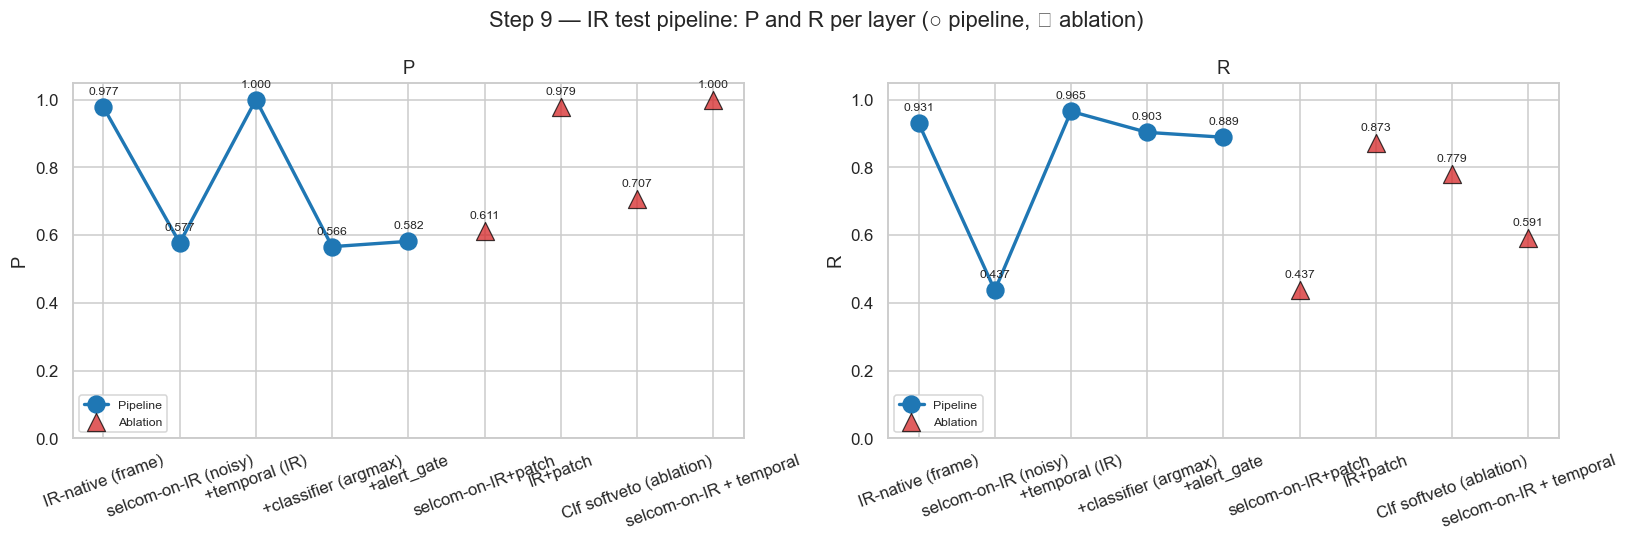

In [24]:
# Step 9 plot 1 — P / R per pipeline layer
def plot_pipeline_PR_labelled(df, pipeline_stages, ablation_stages, stage_label_map, title):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, metric in zip(axes, ('P', 'R')):
        pipe = df[df['stage'].isin(pipeline_stages)].copy()
        pipe['lbl'] = pipe['stage'].map(stage_label_map)
        pipe = pipe.set_index('stage').loc[pipeline_stages].reset_index()
        pipe['lbl'] = pipe['stage'].map(stage_label_map)
        abl = df[df['stage'].isin(ablation_stages)].copy()
        abl['lbl'] = abl['stage'].map(stage_label_map)
        ax.plot(pipe['lbl'], pipe[metric], '-o', markersize=11, linewidth=2.2,
                color='tab:blue', label='Pipeline')
        ax.scatter(abl['lbl'], abl[metric], marker='^', s=140,
                    color='tab:red', edgecolor='black', linewidth=0.8, alpha=0.75,
                    label='Ablation')
        for _, row in pd.concat([pipe, abl]).iterrows():
            ax.annotate(f"{row[metric]:.3f}", (row['lbl'], row[metric]),
                        textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
        ax.set_ylim(0, 1.05); ax.set_ylabel(metric); ax.set_title(metric)
        ax.tick_params(axis='x', rotation=20)
        ax.legend(loc='lower left', fontsize=8)
    plt.suptitle(title)
    plt.tight_layout(); plt.show()

plot_pipeline_PR_labelled(all_ir, PIPELINE_IR, ABLATION_IR, STAGE_LABEL_IR,
    'Step 9 — IR test pipeline: P and R per layer (○ pipeline, △ ablation)')

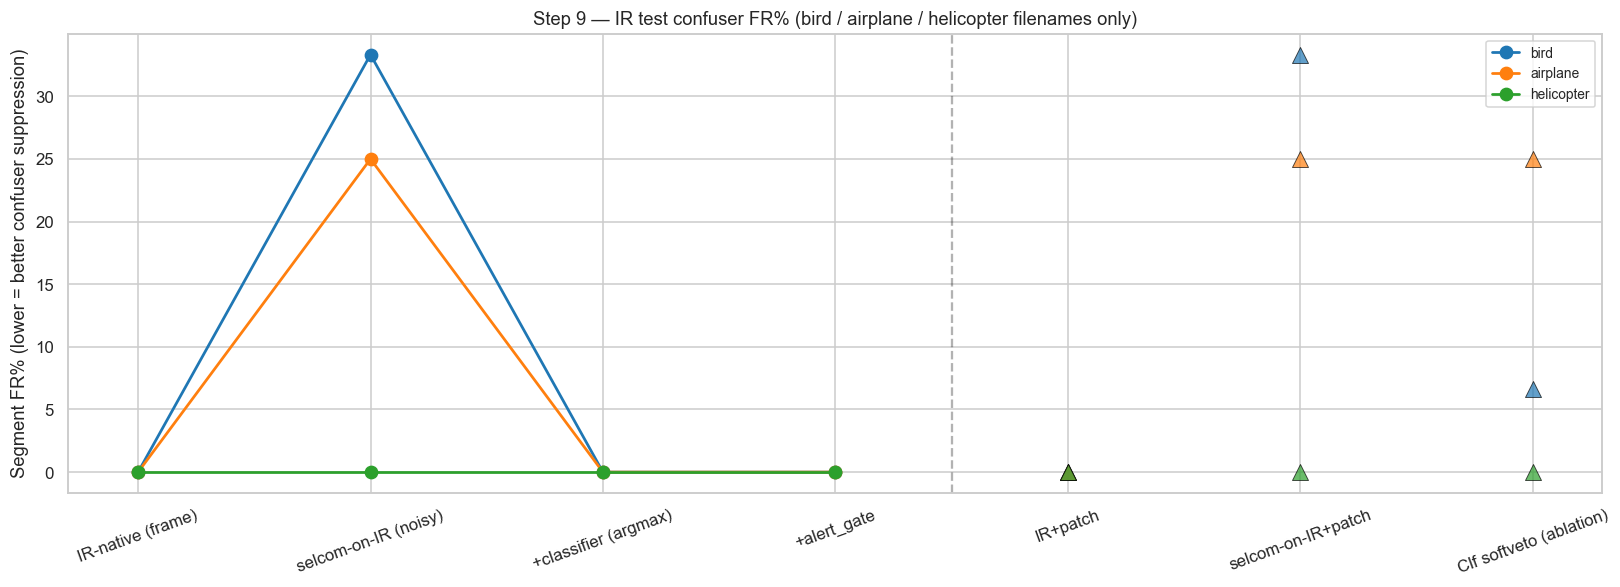

In [25]:
# Step 9 plot 2 — per-confuser-category segment FR% on IR test (BIRD / AIRPLANE / HELICOPTER only)
PIPELINE_IR_CONF = [s for s in PIPELINE_IR if not s.endswith('__temporal')]
ABLATION_IR_CONF = [s for s in ABLATION_IR if not s.endswith('__temporal')]
order_ir = PIPELINE_IR_CONF + ABLATION_IR_CONF
labels_ir = [STAGE_LABEL_IR[s] for s in order_ir]
CONF_CATS_IR = ['bird', 'airplane', 'helicopter']
conf_cats_ir = [c for c in CONF_CATS_IR if c in IR_CONF['category'].unique()]

if conf_cats_ir:
    fig, ax = plt.subplots(figsize=(15, 5.5))
    palette = sns.color_palette('tab10', len(conf_cats_ir))
    for cat, color in zip(conf_cats_ir, palette):
        sub = IR_CONF[IR_CONF['category'] == cat]
        sub = sub.set_index('stage').reindex(order_ir).reset_index()
        pipe_mask = sub['stage'].isin(PIPELINE_IR_CONF)
        ax.plot(labels_ir[:len(PIPELINE_IR_CONF)], sub[pipe_mask]['fr_seg_pct'].values,
                '-o', markersize=8, linewidth=1.8, color=color, label=cat)
        ax.scatter(labels_ir[len(PIPELINE_IR_CONF):],
                    sub[~pipe_mask]['fr_seg_pct'].values,
                    marker='^', s=110, color=color, edgecolor='black', linewidth=0.6, alpha=0.7)
    ax.axvline(x=len(PIPELINE_IR_CONF) - 0.5, color='black', linestyle='--', alpha=0.3)
    ax.set_ylabel('Segment FR% (lower = better confuser suppression)')
    ax.set_title('Step 9 — IR test confuser FR% (bird / airplane / helicopter filenames only)')
    ax.legend(loc='upper right', fontsize=9); ax.tick_params(axis='x', rotation=20)
    plt.tight_layout(); plt.show()
else:
    print('No bird/airplane/helicopter categories in ir_test confuser CSV.')

---
## Aggregate across all datasets

Pipeline stages rolled up across every evaluated dataset, **with IR native and IR grayscale tracked separately** (real IR sensor vs cross-modal grayscale-RGB fallback — very different inputs).

- `base_ir_native` = ir_v3b on real IR frames (antiuav, svanstrom, ir_test)
- `base_ir_grayscale` = ir_v3b run on grayscale-RGB (drone_video, rgb_test)
- `+classifier` = **production deployment per dataset**: argmax for paired/IR-primary (antiuav, svanstrom, ir_test) + softveto τ=0.95 for RGB-only/grayscale (drone_video, rgb_test). This is the rule the system actually ships.

The `n_ds` column shows how many datasets contributed to each stage's row — useful for spotting apples-to-oranges comparisons.

**Read:** one row per architecture/stage, columns are the global P/R/F1 and frame-level FP%/TN%. Color: red→green per column.


In [26]:
# Aggregate: drone P/R/F1 + frame-level FP%/TN% across ALL datasets per stage
def _safe_div(a, b):
    return float(a) / float(b) if b else 0.0

# 1) Pull TP/FP/FN per stage per dataset
agg_rows = []

# antiuav / svanstrom — use per-dataset CSV via per_size_detail.csv (or rebuild from detection)
def _det_tpfn(model, ds):
    df = pd.read_csv(DET / f'{model}_{ds}_detection.csv')
    r = df[df['size']=='all'].iloc[0]
    return int(r['TP']), int(r['FP']), int(r['FN'])

def _fl_fp_tn(model, ds):
    df = pd.read_csv(DET / f'{model}_{ds}_frame_level.csv')
    r = df[df['size']=='all'].iloc[0]
    fp_frames = int(r['FP']); tn_frames = int(r['TN'])
    return fp_frames, tn_frames, fp_frames + tn_frames

# antiuav & svanstrom: argmax classifier; drone_video & rgb_test: soft-veto; ir_test: argmax IR.
# Aggregate stages we care about: base_rgb, base_ir, +temporal, +alert_gate, +classifier(final)
DS_N_ALL = {'antiuav': 1000, 'svanstrom': 1000,
             'drone_video': int(DV_AGG[(DV_AGG['stage']=='S0_rgb') & (DV_AGG['size']=='all')]['n_frames'].iloc[0]),
             'rgb_test': 796, 'ir_test': 690}
def _add(stage, ds, tp, fp, fn, fp_frames=None, tn_frames=None, n_neg=None):
    agg_rows.append({'stage': stage, 'dataset': ds, 'n': DS_N_ALL.get(ds, 0),
                      'TP': tp, 'FP': fp, 'FN': fn,
                      'FP_frames': fp_frames, 'TN_frames': tn_frames, 'n_neg': n_neg})

# Anti-UAV / Svanstrom — IR is NATIVE (real IR sensor)
for ds in ('antiuav', 'svanstrom'):
    tp,fp,fn = _det_tpfn(RGB, ds); fpf,tnf,nn = _fl_fp_tn(RGB, ds)
    _add('base_rgb', ds, tp, fp, fn, fpf, tnf, nn)
    tp,fp,fn = _det_tpfn(IR, ds); fpf,tnf,nn = _fl_fp_tn(IR, ds)
    _add('base_ir_native', ds, tp, fp, fn, fpf, tnf, nn)
    # +temporal (RGB), +alert_gate (RGB), classifier (production = argmax for paired)
    for stage_name, prefix in [('+temporal', 'temporal'),
                                ('+alert_gate', 'alert_gate'),
                                ('+classifier', 'classifier_sa32')]:
        try:
            f = DET / (f'{prefix}_{RGB}_{ds}.csv' if prefix != 'classifier_sa32'
                       else f'classifier_sa32_{ds}.csv')
            r = pd.read_csv(f).iloc[0]
            _add(stage_name, ds, int(r['TP']), int(r['FP']), int(r['FN']))
        except FileNotFoundError:
            pass

# drone_video — IR is GRAYSCALE (cross-modal fallback). Production = softveto.
for stage_key, stage_name in [('S0_rgb','base_rgb'),
                                ('S0_ir_grayscale','base_ir_grayscale'),
                                ('temporal__S0_rgb','+temporal'),
                                ('alert_gate__S2_rgb_patch','+alert_gate'),
                                ('S4_clf_softveto','+classifier')]:
    sub = DV_AGG[(DV_AGG['stage']==stage_key) & (DV_AGG['size']=='all')]
    if sub.empty:
        sub = DV_AGG[DV_AGG['stage']==stage_key]
    if not sub.empty:
        r = sub.iloc[0]
        fpf = r.get('frame_FP'); tnf = r.get('frame_TN'); nf = r.get('n_frames')
        n_neg = (fpf + tnf) if (pd.notna(fpf) and pd.notna(tnf)) else None
        _add(stage_name, 'drone_video', int(r['TP']), int(r['FP']), int(r['FN']),
             int(fpf) if pd.notna(fpf) else None,
             int(tnf) if pd.notna(tnf) else None,
             int(n_neg) if n_neg is not None else None)

# rgb_test — IR is GRAYSCALE. Production classifier = softveto (the S4_clf rows in this CSV are softveto).
RGB_AGG_FULL = pd.read_csv(FPA / 'eval_rgb_test_aggregate.csv')
for stage_key, stage_name in [('S0_rgb','base_rgb'),
                                ('S0_ir','base_ir_grayscale'),
                                ('S4_clf','+classifier'),
                                ('S4_clf_patch','+alert_gate')]:
    sub = RGB_AGG_FULL[(RGB_AGG_FULL['stage']==stage_key) & (RGB_AGG_FULL['size']=='all')]
    if not sub.empty:
        r = sub.iloc[0]
        _add(stage_name, 'rgb_test', int(r['TP']), int(r['FP']), int(r['FN']))

# ir_test — IR is NATIVE. Production classifier = argmax (the S4_clf row is argmax here).
IR_AGG_FULL = pd.read_csv(FPA / 'eval_ir_test_aggregate.csv')
for stage_key, stage_name in [('S0_ir','base_ir_native'),
                                ('S0_rgb','base_rgb'),
                                ('S4_clf','+classifier'),
                                ('S4_clf_patch','+alert_gate')]:
    sub = IR_AGG_FULL[(IR_AGG_FULL['stage']==stage_key) & (IR_AGG_FULL['size']=='all')]
    if not sub.empty:
        r = sub.iloc[0]
        _add(stage_name, 'ir_test', int(r['TP']), int(r['FP']), int(r['FN']))

agg = pd.DataFrame(agg_rows)
# Roll up per stage across all datasets
roll = agg.groupby('stage').agg(n=('n','sum'),
                                  TP=('TP','sum'), FP=('FP','sum'), FN=('FN','sum'),
                                  FP_frames=('FP_frames','sum'), TN_frames=('TN_frames','sum'),
                                  n_neg=('n_neg','sum')).reset_index()
roll['P']  = roll.apply(lambda r: _safe_div(r.TP, r.TP+r.FP), axis=1)
roll['R']  = roll.apply(lambda r: _safe_div(r.TP, r.TP+r.FN), axis=1)
roll['F1'] = roll.apply(lambda r: _safe_div(2*r.P*r.R, r.P+r.R), axis=1)
roll['FP%'] = roll.apply(lambda r: 100*_safe_div(r.FP_frames, r.n_neg) if r.n_neg else None, axis=1)
roll['TN%'] = roll.apply(lambda r: 100*_safe_div(r.TN_frames, r.n_neg) if r.n_neg else None, axis=1)
# Order stages logically
order = ['base_rgb','base_ir_native','base_ir_grayscale','+temporal','+classifier','+alert_gate']
roll['_o'] = roll['stage'].map({s:i for i,s in enumerate(order)})
roll = roll.sort_values('_o').drop(columns='_o').reset_index(drop=True)

print('Drone — all datasets aggregated (n_datasets per stage shown in n_ds)')
roll_ds_counts = agg.groupby('stage')['dataset'].nunique().rename('n_ds').reset_index()
roll = roll.merge(roll_ds_counts, on='stage')
style_cmp(roll[['stage','n_ds','n','TP','FP','FN','P','R','F1','FP%','TN%']].copy(),
           higher_better=['P','R','F1','TN%','TP'],
           lower_better=['FP','FN','FP%'])


Drone — all datasets aggregated (n_datasets per stage shown in n_ds)


,stage,n_ds,n,TP,FP,FN,P,R,F1,FP%,TN%
0,base_rgb,5.000,4845.000,3333.000,1076.000,817.000,0.756,0.803,0.779,56.516,43.484
1,base_ir_native,3.000,2690.000,1964.000,62.000,124.000,0.969,0.941,0.955,2.149,97.851
2,base_ir_grayscale,2.000,2155.000,653.000,202.000,1451.000,0.764,0.310,0.441,23.016,76.984
3,+temporal,3.000,3359.000,4096.000,2542.000,525.000,0.617,0.886,0.728,—,—
4,+classifier,5.000,4845.000,4679.000,866.000,736.000,0.844,0.864,0.854,26.984,73.016
5,+alert_gate,4.000,3845.000,3371.000,908.000,1009.000,0.788,0.770,0.779,—,—


### Aggregate per size — drone (across paired datasets that have per-size CSVs)

`drone_video` per-size also included where available (small/medium/large) for stage S0 base RGB and S0 base IR-gray.


In [27]:
# Aggregate per-size for drones, IR native vs grayscale split
rows = []
# Anti-UAV + Svanstrom: IR is NATIVE
for ds in ('antiuav', 'svanstrom'):
    for model, mod_label in [(RGB, 'base_rgb'), (IR, 'base_ir_native')]:
        df = pd.read_csv(DET / f'{model}_{ds}_detection.csv')
        for size in ('small','medium','large'):
            r = df[df['size']==size]
            if r.empty: continue
            r = r.iloc[0]
            rows.append({'stage': mod_label, 'size': size,
                          'TP': int(r['TP']), 'FP': int(r['FP']), 'FN': int(r['FN'])})
# drone_video: IR is GRAYSCALE
for stage_key, stage_label in [('S0_rgb','base_rgb'),('S0_ir_grayscale','base_ir_grayscale')]:
    sub = DV_AGG[(DV_AGG['stage']==stage_key) & (DV_AGG['size'].isin(['small','medium','large']))]
    for _, r in sub.iterrows():
        rows.append({'stage': stage_label, 'size': r['size'],
                      'TP': int(r['TP']), 'FP': int(r['FP']), 'FN': int(r['FN'])})

ps = pd.DataFrame(rows).groupby(['stage','size']).sum().reset_index()
ps['n_gt'] = ps['TP'] + ps['FN']
ps['P'] = ps.apply(lambda r: r.TP/(r.TP+r.FP) if (r.TP+r.FP) else 0.0, axis=1)
ps['R'] = ps.apply(lambda r: r.TP/(r.TP+r.FN) if (r.TP+r.FN) else 0.0, axis=1)
ps['F1'] = ps.apply(lambda r: 2*r.P*r.R/(r.P+r.R) if (r.P+r.R) else 0.0, axis=1)
ps['size'] = pd.Categorical(ps['size'], ['small','medium','large'], ordered=True)
ps = ps.sort_values(['stage','size']).reset_index(drop=True)
ps = ps[['stage','size','n_gt','TP','FP','FN','P','R','F1']]
style_cmp(ps, higher_better=['P','R','F1','TP'], lower_better=['FP','FN'], group='stage')


,stage,size,n_gt,TP,FP,FN,P,R,F1
0,base_ir_grayscale,small,213.000,75.000,80.000,138.000,0.484,0.352,0.408
1,base_ir_grayscale,medium,418.000,167.000,31.000,251.000,0.843,0.400,0.542
2,base_ir_grayscale,large,603.000,234.000,74.000,369.000,0.760,0.388,0.514
3,base_ir_native,small,14.000,10.000,1.000,4.000,0.909,0.714,0.800
4,base_ir_native,medium,1310.000,1240.000,45.000,70.000,0.965,0.947,0.956
5,base_ir_native,large,71.000,69.000,1.000,2.000,0.986,0.972,0.979
6,base_rgb,small,313.000,208.000,289.000,105.000,0.419,0.665,0.514
7,base_rgb,medium,1602.000,1478.000,386.000,124.000,0.793,0.923,0.853
8,base_rgb,large,672.000,548.000,139.000,124.000,0.798,0.815,0.806


### Aggregate confuser FR% across all datasets, per category — split by IR type

Lower FR% = better. **Two tables** — one for datasets where IR is native (ir_test) and one for grayscale-fallback IR (drone_video + rgb_test). The `+classifier` column is **production deployment**: argmax for ir_test, softveto τ=0.95 for drone_video / rgb_test.

This is why the previous mixed table looked weird — it summed apples (rgb_test 0% FR on birds) into oranges (drone_video 21% FR on birds against attacking flocks). Splitting by IR type also separates the deployment rules, so each cell is a fair rollup.


In [28]:
# Aggregate confuser FR% — production stages only, split IR-native vs IR-grayscale
def _conf_long_v2(df, ir_type):
    """Returns one row per (cat, common_stage) with fp_boxes/n_frames and ir_type label."""
    sub = df.copy()
    sub['cat'] = sub['category'].replace({'birds':'bird','airplanes':'airplane','helicopters':'helicopter'})
    sub = sub[sub['cat'].isin(['bird','airplane','helicopter'])]
    sub['ir_type'] = ir_type
    return sub

dv    = pd.read_csv(FPA / 'eval_drone_video_confuser_aggregate.csv')
rgb_c = pd.read_csv(FPA / 'eval_rgb_test_confuser.csv')
ir_c  = pd.read_csv(FPA / 'eval_ir_test_confuser.csv')

# Per dataset, the meaningful pipeline stages (production)
# drone_video (softveto): S0_rgb, S0_ir_grayscale, S4_clf_softveto, S4_softveto_patch
# rgb_test (softveto):    S0_rgb, S0_ir,           S4_clf,           S4_clf_patch
# ir_test (argmax):       S0_rgb, S0_ir,           S4_clf,           S4_clf_patch

def _label_stages(df, mapping):
    """Map per-CSV stage names to canonical pipeline labels."""
    df = df.copy()
    df['stage_canon'] = df['stage'].map(mapping)
    return df[df['stage_canon'].notna()]

GRAY_MAP = {
    'S0_rgb': 'base_rgb', 'S0_ir_grayscale': 'base_ir', 'S0_ir': 'base_ir',
    'S4_clf_softveto': '+classifier', 'S4_clf': '+classifier',
    'S4_softveto_patch': '+alert_gate', 'S4_clf_patch': '+alert_gate',
}
NATIVE_MAP = {
    'S0_rgb': 'base_rgb', 'S0_ir': 'base_ir',
    'S4_clf': '+classifier', 'S4_clf_patch': '+alert_gate',
}

# Grayscale-IR datasets: drone_video + rgb_test
gray = pd.concat([
    _conf_long_v2(_label_stages(dv, GRAY_MAP), 'grayscale'),
    _conf_long_v2(_label_stages(rgb_c, GRAY_MAP), 'grayscale'),
], ignore_index=True)
roll_gray = (gray.groupby(['cat','stage_canon']).agg(fp_boxes=('fp_boxes','sum'),
                                                       n_frames=('n_frames','sum')).reset_index())
roll_gray['FR%'] = 100 * roll_gray['fp_boxes'] / roll_gray['n_frames'].replace(0, np.nan)
piv_gray = (roll_gray.pivot(index='cat', columns='stage_canon', values='FR%')
            .reindex(columns=['base_rgb','base_ir','+classifier','+alert_gate'])
            .reindex(index=['bird','airplane','helicopter']).round(2))
n_gray = gray.groupby('cat')['n_frames'].first().to_dict()
piv_gray.insert(0, 'n', piv_gray.index.map(n_gray).fillna(0).astype('Int64'))

# Native-IR dataset: ir_test
native = _conf_long_v2(_label_stages(ir_c, NATIVE_MAP), 'native')
roll_nat = (native.groupby(['cat','stage_canon']).agg(fp_boxes=('fp_boxes','sum'),
                                                       n_frames=('n_frames','sum')).reset_index())
roll_nat['FR%'] = 100 * roll_nat['fp_boxes'] / roll_nat['n_frames'].replace(0, np.nan)
piv_nat = (roll_nat.pivot(index='cat', columns='stage_canon', values='FR%')
            .reindex(columns=['base_rgb','base_ir','+classifier','+alert_gate'])
            .reindex(index=['bird','airplane','helicopter']).round(2))
n_nat = native.groupby('cat')['n_frames'].first().to_dict()
piv_nat.insert(0, 'n', piv_nat.index.map(n_nat).fillna(0).astype('Int64'))

print('IR-native confusers (ir_test — production = argmax classifier)')
display(piv_nat.style.background_gradient(cmap=_RYG_BAD, axis=None, vmin=0, vmax=100).format('{:.2f}', na_rep='—'))
print()
print('IR-grayscale confusers (drone_video + rgb_test — production = softveto τ=0.95)')
display(piv_gray.style.background_gradient(cmap=_RYG_BAD, axis=None, vmin=0, vmax=100).format('{:.2f}', na_rep='—'))


IR-native confusers (ir_test — production = argmax classifier)

stage_canon,n,base_rgb,base_ir,+classifier,+alert_gate
cat,,,,,
bird,43.00,27.91,0.00,0.00,0.00
airplane,24.00,20.83,0.00,0.00,0.00
helicopter,20.00,15.00,0.00,5.00,0.00



IR-grayscale confusers (drone_video + rgb_test — production = softveto τ=0.95)


stage_canon,n,base_rgb,base_ir,+classifier,+alert_gate
cat,,,,,
bird,352.00,53.40,4.26,24.26,14.68
airplane,304.00,44.08,22.37,33.22,12.17
helicopter,594.00,23.06,7.07,21.89,15.82


## Patch Verifier vs MLP V5 Verifier — Head-to-Head (2026-05-30)

> **Script:** `eval/eval_pipeline_v5_quick.py --n-images 300`
> **Detector:** FT4 R3 (Yolo26n_selcom_confuser_ft4_1280) | **RGB conf:** 0.25
> **Both verifiers per-frame at thr=0.5**, scored on the *same* detections per surface.
> **V5 MLP:** production `_v5_selcom_pure_1x8/classifiers/mlp_v5.pt` (517-D p3+p5 YOLO features).

### F1 / hallucination by surface (per-frame, n=300/surface)

| Surface | bare F1 | patch v2 F1 | **V5 MLP F1** | Δ (MLP−patch) | patch halluc/img | **MLP halluc/img** |
|---|---|---|---|---|---|---|
| Svanström (IoP) | 0.601 | 0.750 | **0.836** | **+0.086** | 0.157 | **0.040** |
| Anti-UAV (IoU) | 0.984 | 0.984 | 0.982 | −0.002 | 0.010 | 0.010 |
| selcom_val (IoP) | 0.591 | 0.591 | **0.607** | **+0.015** | 0.073 | **0.020** |
| rgb_dataset_test (IoU) | 0.909 | **0.862** | 0.784 | **−0.078** | 0.047 | **0.017** |
| confuser_test (halluc only) | 0.233/img | 0.100/img | **0.013/img** | 7.5× cleaner | 0.100 | **0.013** |

### Speed (per detection)

| Surface | patch v2 ms/det | V5 MLP ms/det | MLP advantage |
|---|---|---|---|
| Svanström | 80.9 | 1.77 | **45.7×** |
| confuser_test | 79.6 | 1.45 | **55.0×** |
| Anti-UAV | 108.7 | 1.76 | **61.9×** |
| selcom_val | 93.8 | 1.31 | **71.7×** |
| rgb_dataset_test | 98.5 | 1.85 | **53.2×** |

Per-frame pipeline overhead: **V5 MLP +~2%** on top of YOLO vs **patch v2 +70–230%**.

### Per-frame vs alert-gated (V5 MLP)

| Surface | V5 PF F1 | V5 AG F1 | Δ F1 |
|---|---|---|---|
| Svanström | 0.836 | 0.792 | −0.044 |
| Anti-UAV | 0.982 | 0.982 | 0.000 |
| selcom_val | 0.607 | 0.599 | −0.008 |
| rgb_dataset_test | 0.784 | 0.788 | +0.005 |

Alert-gating saves <0.2 ms but costs up to 4.4 pp F1 (Svan) — **run the MLP per-frame**.

### Verdict

- **MLP wins F1 on 3/5 surfaces** (Svan +8.6 pp, selcom +1.5 pp, confuser 7.5× cleaner), **ties Anti-UAV**, and **suppresses hallucinations on all 5 surfaces**.
- **Single loss: rgb_dataset_test drone-recall** (−7.8 pp F1) — the photo-style carve-out. A Svanström-drone-weight rebalance (2.5→1.5) was tried and is a **no-op** (recall unchanged), because the gap is feature-space *coverage*, not gradient *share*.
- **MLP is 46–72× faster per detection** (1.3–1.9 ms vs 80–109 ms).

→ **Ship V5 MLP everywhere except photo-style RGB content; keep patch v2 as the fallback on that surface.**
